# EDA & Dimensionality Reduction — GDSC2 Drug Response

**Goals**
1. Load and prepare data exactly as PathXDRP's training pipeline does
2. Exploratory analysis: IC50 distributions, drug/cell coverage, pathway statistics, expression landscape
3. Dimensionality reduction of the cell-line expression space (t-SNE / UMAP)
4. Hyperparameter optimisation of t-SNE / UMAP via **Particle Swarm Optimisation (PSO)** — maximise class separability (silhouette score) over tissue types
5. Visualise embeddings coloured by tissue, drug pathway, mean sensitivity, and resistance
6. Interpret: does the embedding structure suggest cross-attention over pathways adds signal beyond raw expression clustering?

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────
import sys, warnings, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

import umap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
SEED = 42
ROOT = Path('.').resolve()
print('ROOT:', ROOT)

ROOT: D:\Masters\GNN Drug Discovery


In [2]:
# ── 1. Load data exactly as PathXDRP does ──────────────────────────────────
# We reuse pathxdrp.data.loader so the preprocessing is identical.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pathxdrp.data.loader import build_master_df

print('Building master DF (same pipeline as training)...')
df, expr_matrix = build_master_df(version='GDSC2', require_smiles=True)
print(f'Response rows  : {len(df):,}  ({df.DRUG_ID.nunique()} drugs × {df.COSMIC_ID.nunique()} cells)')
print(f'Expression     : {expr_matrix.shape[0]} cell lines × {expr_matrix.shape[1]} genes')

Building master DF (same pipeline as training)...
Loading response IC50 file...
  Response: 242,036 rows, 295 drugs, 969 cells
Loading cell line metadata...
Loading drug SMILES...
  Drugs with SMILES: 621
Loading expression matrix...
  COSMIC<->DepMap mapping: 946 cell lines
  Loading DepMap expression matrix (483 MB)...
    -> 1673 models x 19,193 genes loaded in 9.1s
  Filtering to 697/1673 models with COSMIC mapping
  Z-scoring expression matrix per gene...
    -> done in 0.3s
  Expression matrix ready: 697 cell lines x 19,193 genes
  Kept 207,350/242,036 rows with valid SMILES
  Kept 150,459/207,350 rows with expression data (697 cell lines)
Master DF: 150,459 rows | 247 drugs | 697 cells
Response rows  : 150,459  (247 drugs × 697 cells)
Expression     : 697 cell lines × 19193 genes


In [3]:
# ── 2. Merge in rich annotations ──────────────────────────────────────────
# Compound annotations (TARGET_PATHWAY)
compounds = pd.read_csv(ROOT / 'Compounds-annotation.csv')[['DRUG_ID', 'TARGET', 'TARGET_PATHWAY']]
# Drop any pre-existing columns to avoid _x/_y suffix explosion on re-runs
df = df.drop(columns=['TARGET', 'TARGET_PATHWAY'], errors='ignore')
df = df.merge(compounds, on='DRUG_ID', how='left')

# Tissue / lineage from cosmic_to_depmap
c2d = pd.read_csv(ROOT / 'data/processed/cosmic_to_depmap.csv')[['COSMICID', 'OncotreeLineage', 'OncotreePrimaryDisease']]
c2d['COSMICID'] = c2d['COSMICID'].astype('Int64')  # match int64 COSMIC_ID in df
c2d = c2d.rename(columns={'COSMICID': 'COSMIC_ID'})
df = df.drop(columns=['OncotreeLineage', 'OncotreePrimaryDisease'], errors='ignore')
df = df.merge(c2d, on='COSMIC_ID', how='left')

# Gene tractability — pivot to per-drug attribute
gt = pd.read_csv(ROOT / 'gene_tractabilty_20251009.csv')[['gene_symbol', 'small_molecule', 'type']]

print(df.columns.tolist())
print(df[['TCGA_DESC', 'OncotreeLineage', 'TARGET_PATHWAY', 'PATHWAY_NAME']].nunique())

['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'SMILES', 'tissue_1', 'tissue_2', 'cancer_type', 'msi_status', 'TARGET', 'TARGET_PATHWAY', 'OncotreeLineage', 'OncotreePrimaryDisease']
TCGA_DESC          32
OncotreeLineage    27
TARGET_PATHWAY     24
PATHWAY_NAME       24
dtype: int64


In [4]:
# ── 2b. Master DataFrame — full overview ──────────────────────────────────
print('=' * 70)
print('  MASTER DATAFRAME — FULL OVERVIEW')
print('=' * 70)
print(f'\n  Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns\n')

print('── Columns, dtypes & null counts ─────────────────────────────────────')
col_info = pd.DataFrame({
    'dtype'   : df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().mean() * 100).round(1),
    'n_unique': df.nunique(),
    'sample'  : [str(df[c].dropna().iloc[0]) if df[c].notna().any() else 'NaN'
                 for c in df.columns],
})
print(col_info.to_string())

print('\n── Key cardinalities ─────────────────────────────────────────────────')
for col in ['DRUG_ID', 'DRUG_NAME', 'COSMIC_ID', 'CELL_LINE_NAME',
            'PATHWAY_NAME', 'TARGET_PATHWAY', 'TCGA_DESC', 'OncotreeLineage']:
    if col in df.columns:
        print(f'  {col:<30s}  {df[col].nunique():>4} unique values')

print('\n── Numeric summary (response metrics) ────────────────────────────────')
num_cols = [c for c in ['LN_IC50', 'AUC', 'RMSE', 'Z_SCORE'] if c in df.columns]
print(df[num_cols].describe().round(3).to_string())

print('\n── Concentration range ───────────────────────────────────────────────')
if 'MIN_CONC' in df.columns:
    print(f'  MIN_CONC : {df["MIN_CONC"].min():.4f}  →  {df["MIN_CONC"].max():.4f}')
    print(f'  MAX_CONC : {df["MAX_CONC"].min():.4f}  →  {df["MAX_CONC"].max():.4f}')


  MASTER DATAFRAME — FULL OVERVIEW

  Shape : 150,459 rows  ×  28 columns

── Columns, dtypes & null counts ─────────────────────────────────────
                          dtype  non_null  null_pct  n_unique                                                   sample
DATASET                  object    150459       0.0         1                                                    GDSC2
NLME_RESULT_ID            int64    150459       0.0         1                                                      343
NLME_CURVE_ID             int64    150459       0.0    150459                                                 15946310
COSMIC_ID                 int64    150459       0.0       697                                                   683667
CELL_LINE_NAME           object    150459       0.0       697                                                   PFSK-1
SANGER_MODEL_ID          object    150459       0.0       697                                                SIDM01132
TCGA_DESC            

---
## Part A — Response Distribution EDA

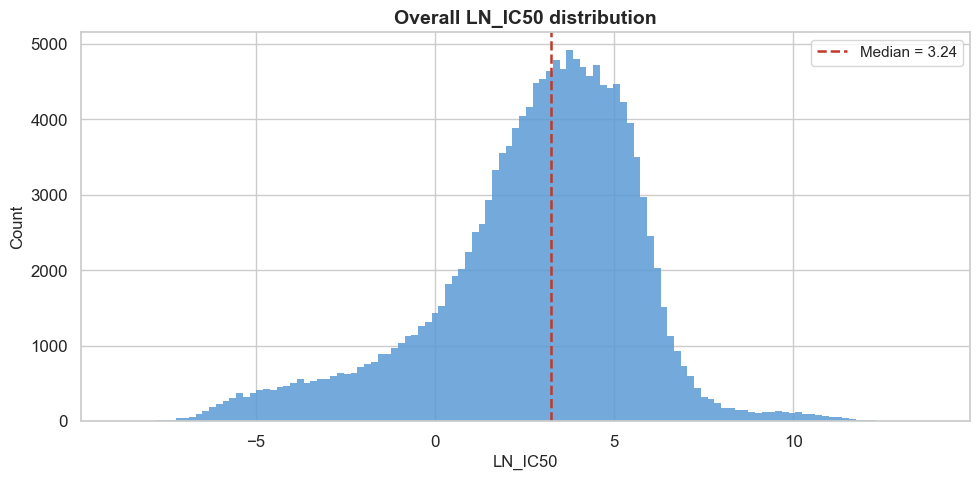

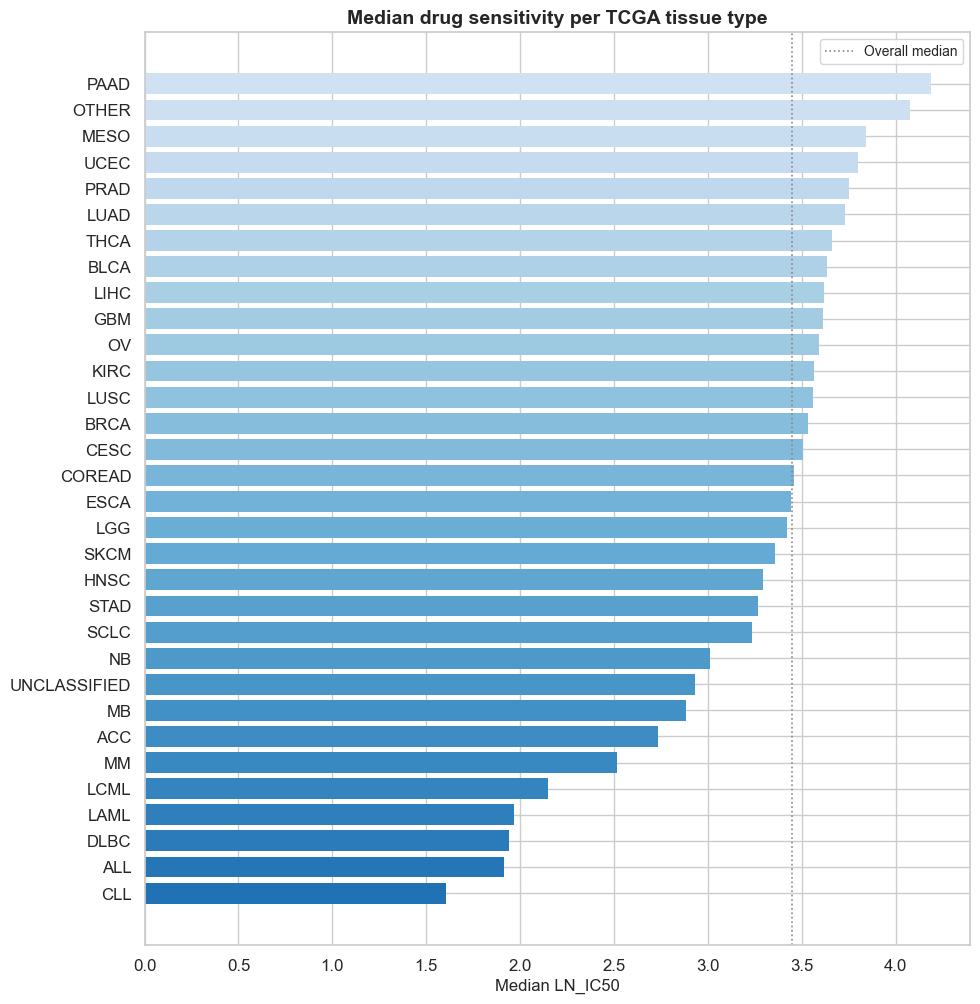

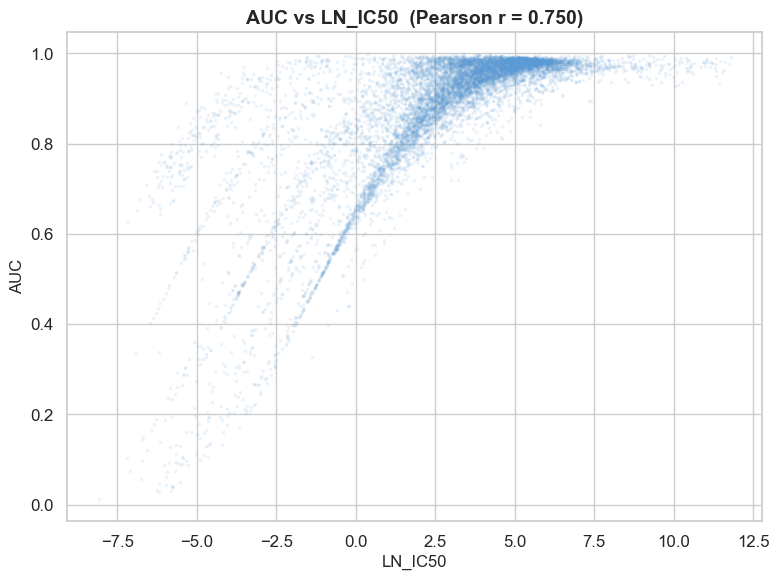

In [5]:
# ── 3a-i. Overall LN_IC50 histogram ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['LN_IC50'].dropna(), bins=120, color='#5B9BD5', edgecolor='none', alpha=0.85)
ax.axvline(df['LN_IC50'].median(), color='#C0392B', linestyle='--', linewidth=1.8,
           label=f'Median = {df["LN_IC50"].median():.2f}')
ax.set_xlabel('LN_IC50', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Overall LN_IC50 distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── 3a-ii. Median LN_IC50 per TCGA tissue ────────────────────────────────
tissue_med = df.groupby('TCGA_DESC')['LN_IC50'].median().sort_values()
n = len(tissue_med)
colors_bar = plt.cm.Blues_r(np.linspace(0.25, 0.80, n))

fig, ax = plt.subplots(figsize=(10, max(6, n * 0.32)))
ax.barh(tissue_med.index, tissue_med.values, color=colors_bar, edgecolor='none')
ax.set_xlabel('Median LN_IC50', fontsize=12)
ax.set_title('Median drug sensitivity per TCGA tissue type', fontsize=14, fontweight='bold')
ax.axvline(tissue_med.median(), color='#888', linestyle=':', linewidth=1.2, label='Overall median')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── 3a-iii. AUC vs LN_IC50 scatter ───────────────────────────────────────
sub = df.sample(10_000, random_state=SEED)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sub['LN_IC50'], sub['AUC'], alpha=0.12, s=6, color='#5B9BD5', linewidths=0)
ax.set_xlabel('LN_IC50', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title(f'AUC vs LN_IC50  (Pearson r = {sub["LN_IC50"].corr(sub["AUC"]):.3f})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


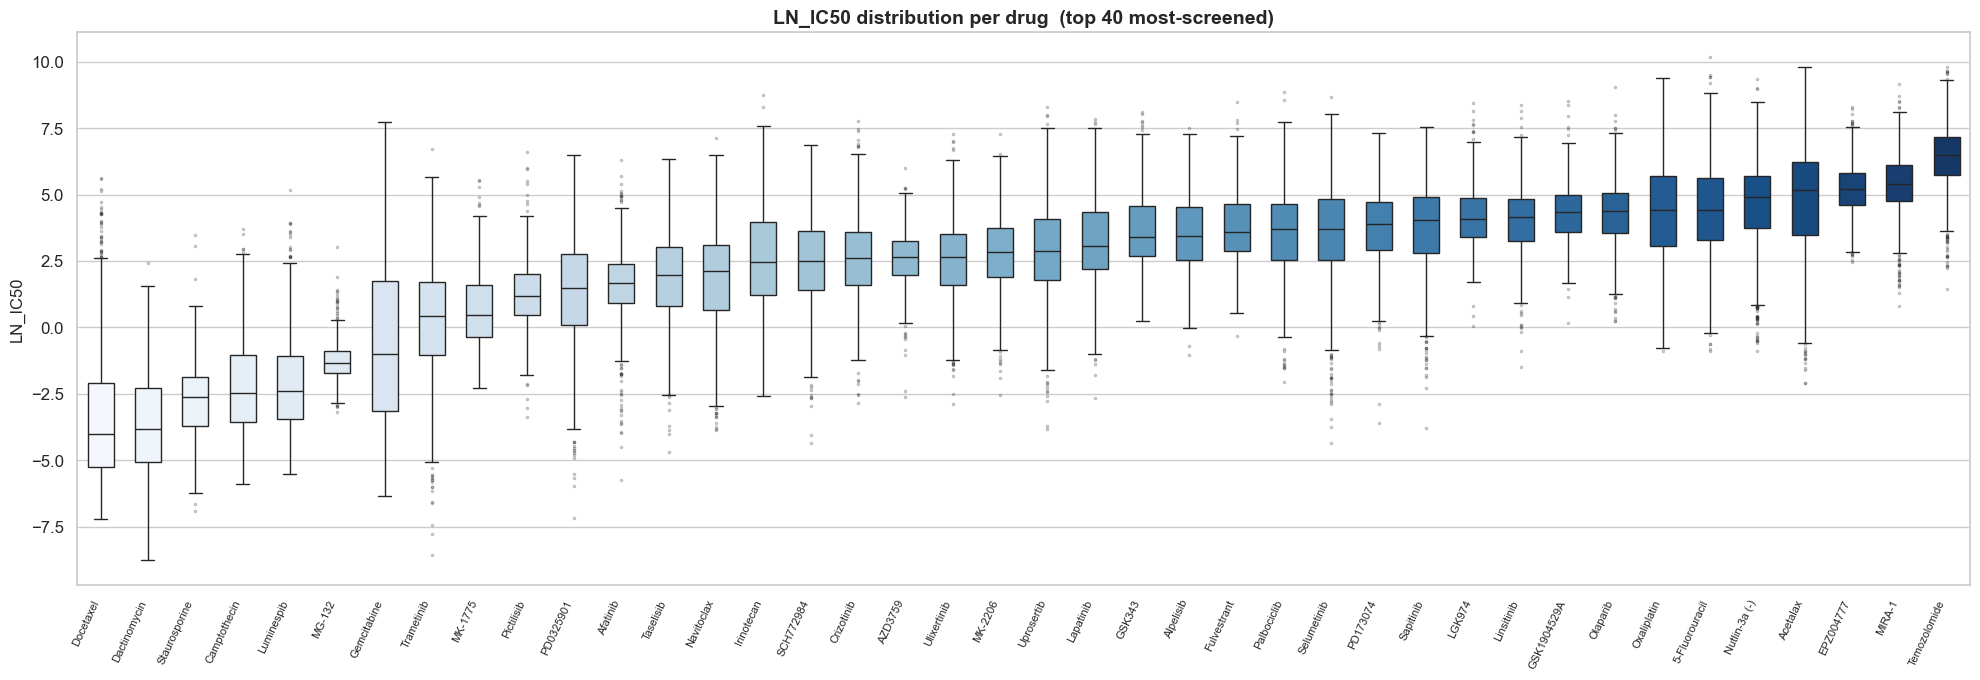

In [6]:
# ── 3b. Per-drug IC50 spread (box-plot top 40 most-screened drugs) ─────────
top_drugs = df['DRUG_NAME'].value_counts().head(40).index
sub_d = df[df['DRUG_NAME'].isin(top_drugs)].copy()
order = sub_d.groupby('DRUG_NAME')['LN_IC50'].median().sort_values().index

fig, ax = plt.subplots(figsize=(20, 7))
sns.boxplot(data=sub_d, x='DRUG_NAME', y='LN_IC50', order=order,
            palette='Blues', width=0.55, fliersize=1.5,
            flierprops=dict(alpha=0.3), ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('LN_IC50', fontsize=12)
ax.set_title('LN_IC50 distribution per drug  (top 40 most-screened)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


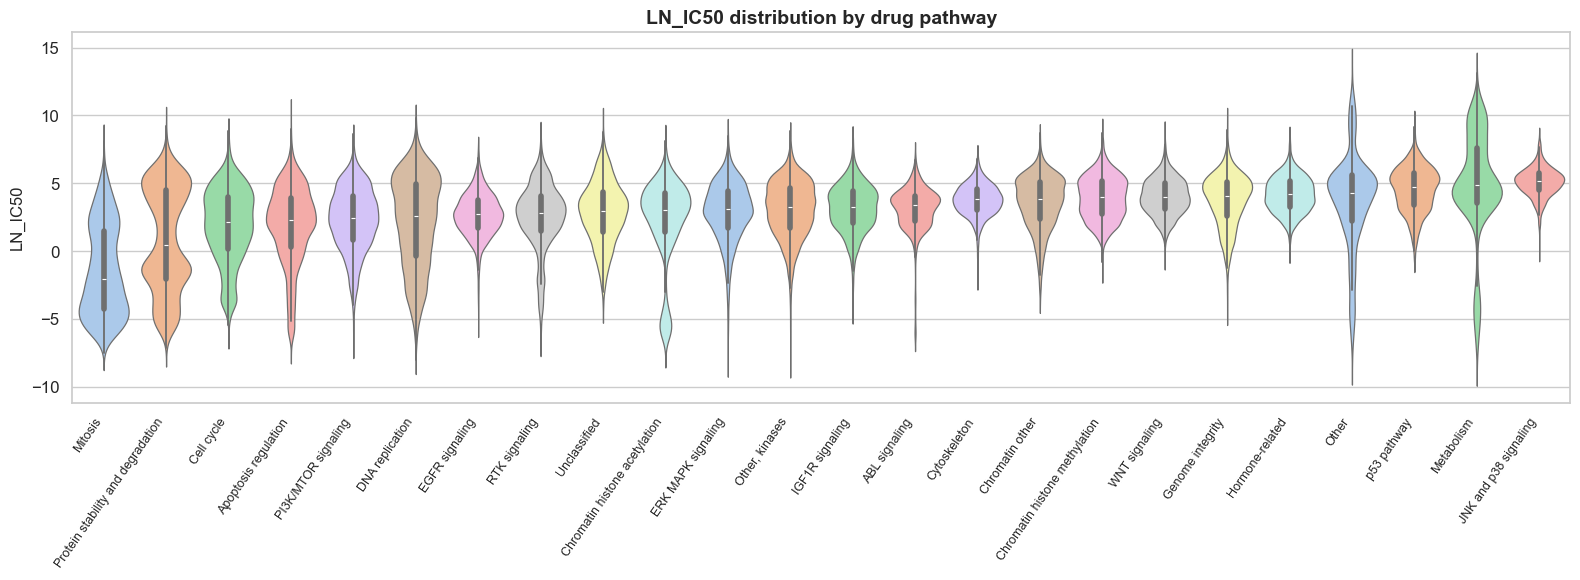

In [7]:
# ── 3c. Per-pathway IC50 distributions ────────────────────────────────────
order_pw = df.groupby('PATHWAY_NAME')['LN_IC50'].median().sort_values().index

fig, ax = plt.subplots(figsize=(16, 6))
sns.violinplot(data=df, x='PATHWAY_NAME', y='LN_IC50', order=order_pw,
               palette='pastel', inner='box', linewidth=0.9, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('LN_IC50', fontsize=12)
ax.set_title('LN_IC50 distribution by drug pathway', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


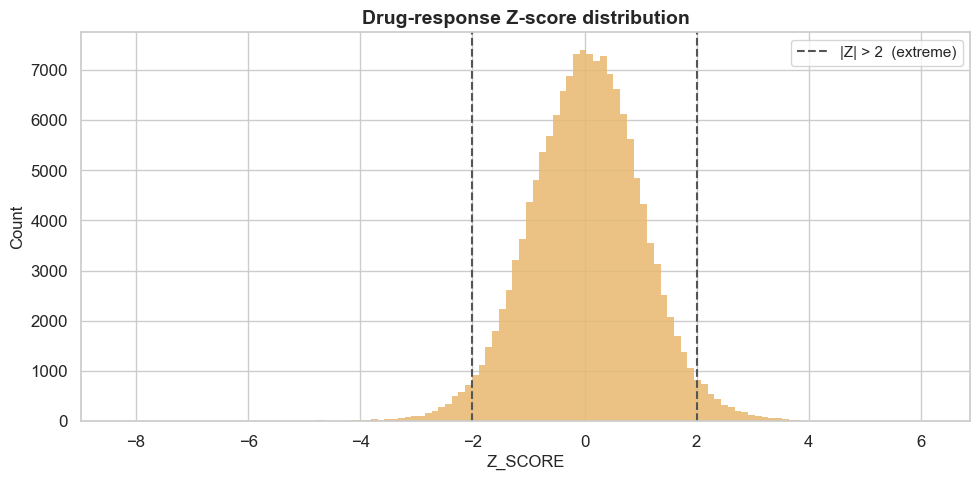

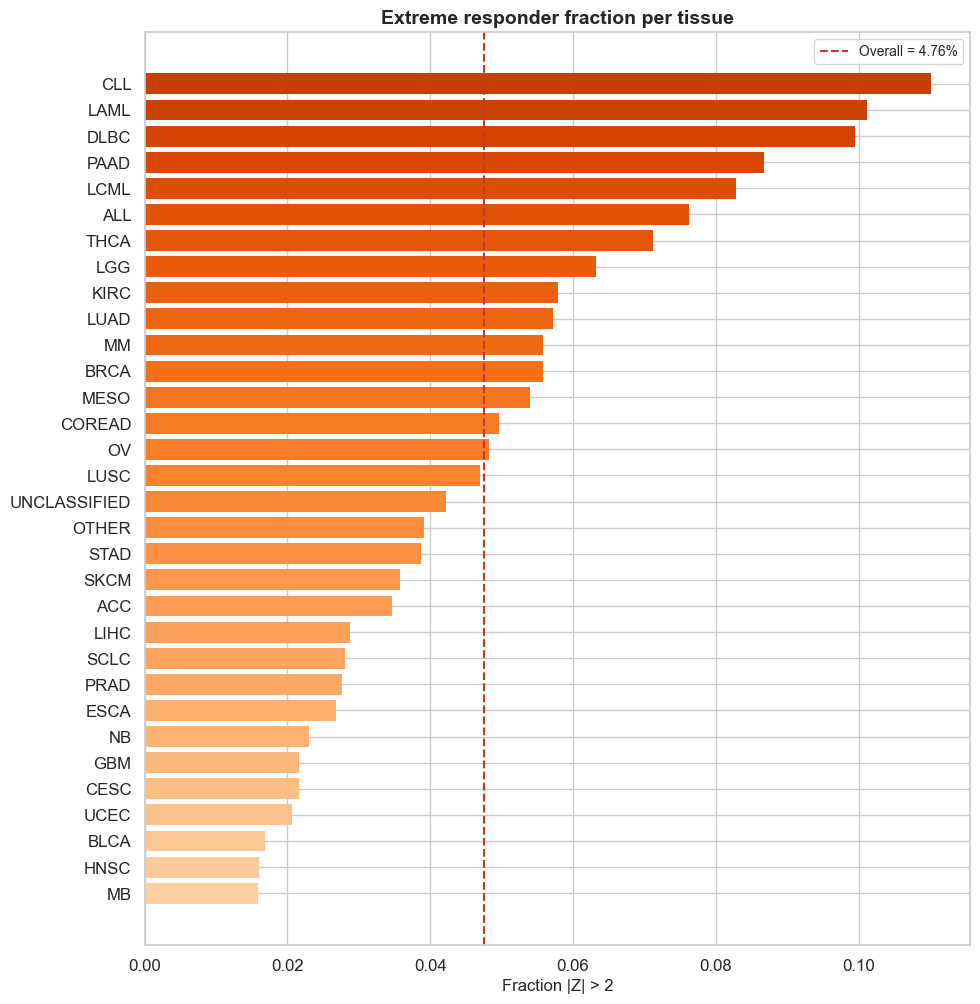

In [8]:
# ── 3d-i. Z_SCORE distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Z_SCORE'].dropna(), bins=120, color='#E8B86D', edgecolor='none', alpha=0.85)
ax.axvline(-2, color='#555', linestyle='--', linewidth=1.5, label='|Z| > 2  (extreme)')
ax.axvline( 2, color='#555', linestyle='--', linewidth=1.5)
ax.set_xlabel('Z_SCORE', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Drug-response Z-score distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── 3d-ii. Fraction of extreme responders per tissue ─────────────────────
extreme_frac = (df['Z_SCORE'].abs() > 2).mean()
tissue_extreme = (df.groupby('TCGA_DESC')
                    .apply(lambda g: (g['Z_SCORE'].abs() > 2).mean())
                    .sort_values(ascending=True))
n = len(tissue_extreme)
colors_bar = plt.cm.Oranges(np.linspace(0.25, 0.80, n))

fig, ax = plt.subplots(figsize=(10, max(6, n * 0.32)))
ax.barh(tissue_extreme.index, tissue_extreme.values, color=colors_bar, edgecolor='none')
ax.axvline(extreme_frac, color='#C0392B', linestyle='--', linewidth=1.5,
           label=f'Overall = {extreme_frac:.2%}')
ax.set_xlabel('Fraction |Z| > 2', fontsize=12)
ax.set_title('Extreme responder fraction per tissue', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## Part B — Coverage & Sparsity

Matrix shape (drugs × cells) : (247, 697)
Overall fill rate            : 87.40%
Drugs screened in >80% cells : 185


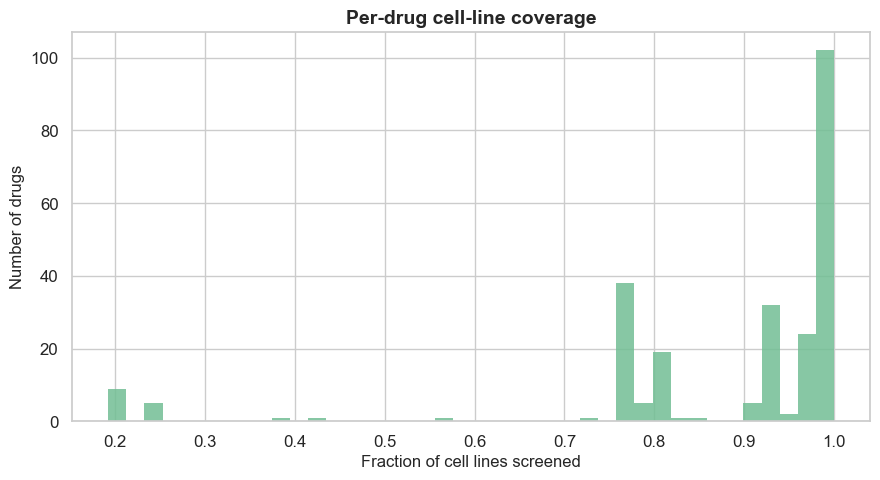

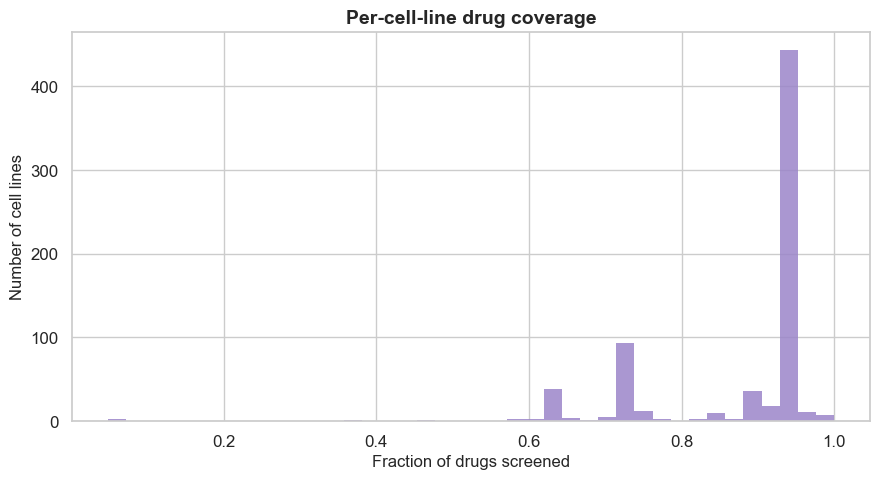

In [9]:
# ── 4a. Drug–cell screening matrix — coverage statistics ──────────────────
pivot = df.pivot_table(index='DRUG_ID', columns='COSMIC_ID', values='LN_IC50', aggfunc='count')
coverage = pivot.notna().sum(axis=1) / pivot.shape[1]
cell_cov  = pivot.notna().sum(axis=0) / pivot.shape[0]

print(f'Matrix shape (drugs × cells) : {pivot.shape}')
print(f'Overall fill rate            : {pivot.notna().mean().mean():.2%}')
print(f'Drugs screened in >80% cells : {(coverage > 0.8).sum()}')

# Per-drug coverage histogram
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(coverage, bins=40, color='#72BE94', edgecolor='none', alpha=0.85)
ax.set_xlabel('Fraction of cell lines screened', fontsize=12)
ax.set_ylabel('Number of drugs', fontsize=12)
ax.set_title('Per-drug cell-line coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-cell-line coverage histogram
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cell_cov, bins=40, color='#9B85C9', edgecolor='none', alpha=0.85)
ax.set_xlabel('Fraction of drugs screened', fontsize=12)
ax.set_ylabel('Number of cell lines', fontsize=12)
ax.set_title('Per-cell-line drug coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


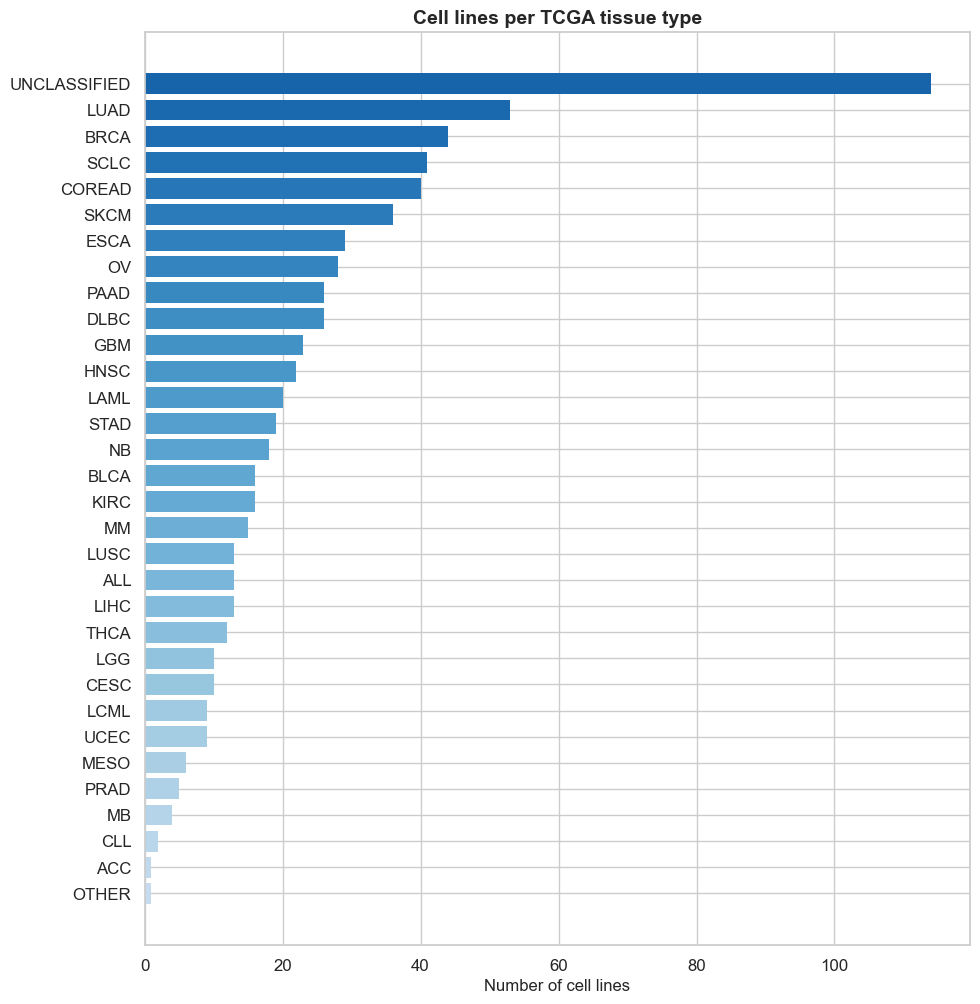

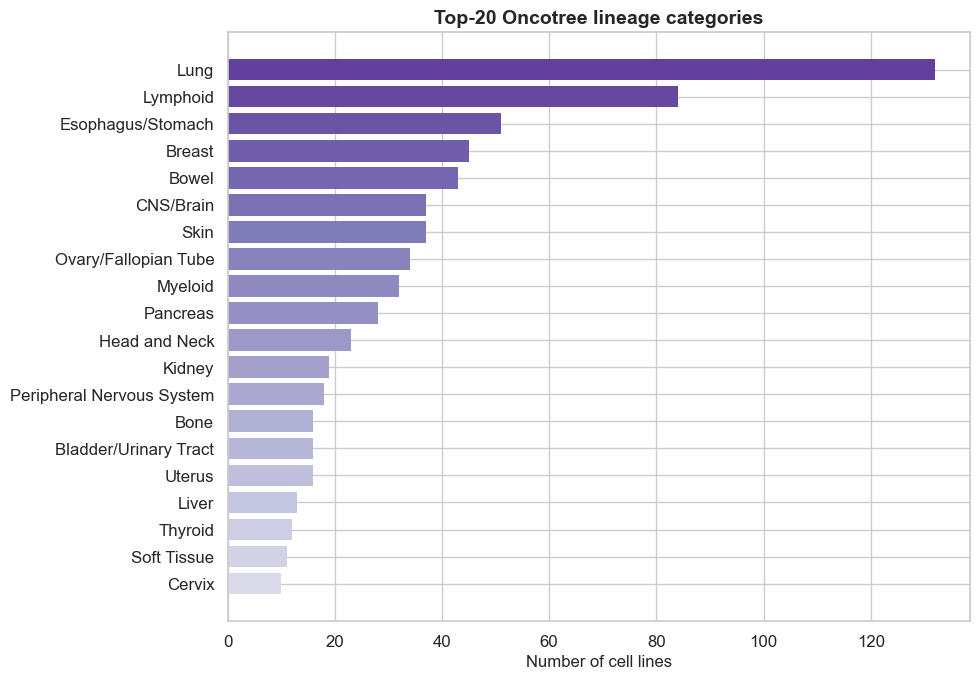

In [10]:
# ── 4b. Cell line tissue distribution ─────────────────────────────────────
cell_meta = df[['COSMIC_ID', 'TCGA_DESC', 'OncotreeLineage']].drop_duplicates('COSMIC_ID')

# TCGA tissue counts
tc = cell_meta['TCGA_DESC'].value_counts().sort_values()
n = len(tc)
colors_bar = plt.cm.Blues(np.linspace(0.25, 0.80, n))

fig, ax = plt.subplots(figsize=(10, max(5, n * 0.32)))
ax.barh(tc.index, tc.values, color=colors_bar, edgecolor='none')
ax.set_xlabel('Number of cell lines', fontsize=12)
ax.set_title('Cell lines per TCGA tissue type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top-20 OncotreeLineage counts
ol = cell_meta['OncotreeLineage'].value_counts().head(20).sort_values()
colors_bar2 = plt.cm.Purples(np.linspace(0.25, 0.80, len(ol)))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(ol.index, ol.values, color=colors_bar2, edgecolor='none')
ax.set_xlabel('Number of cell lines', fontsize=12)
ax.set_title('Top-20 Oncotree lineage categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Part C — Expression / Pathway EDA

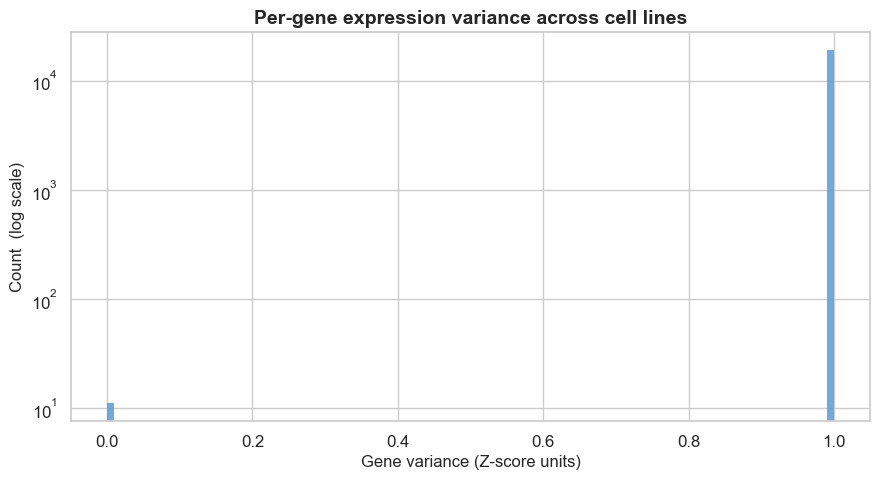

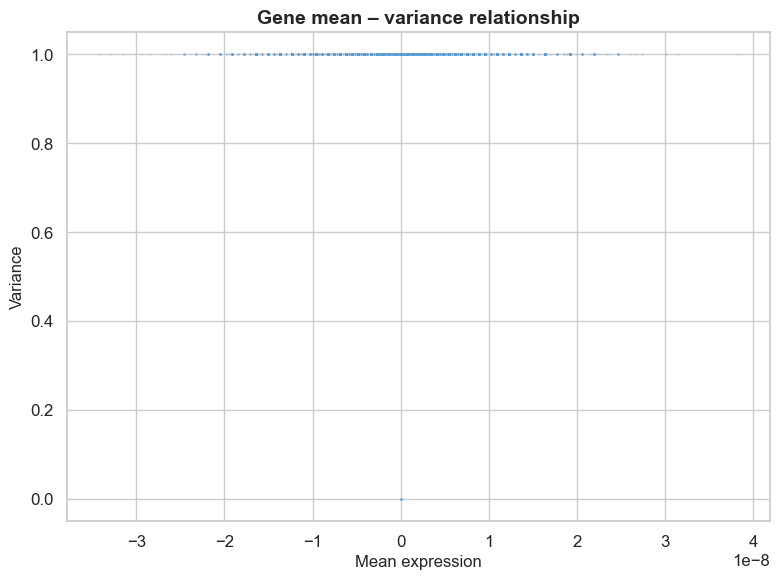

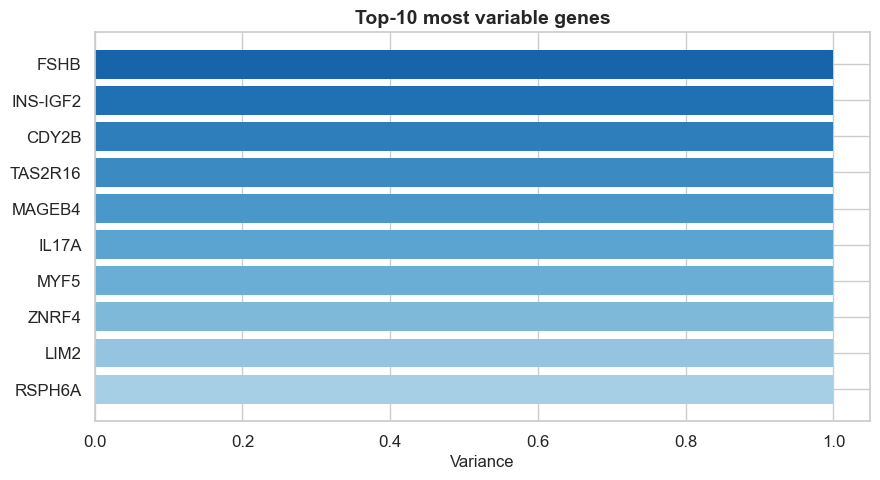

In [11]:
# ── 5a-i. Per-gene expression variance (histogram) ────────────────────────
gene_var  = expr_matrix.var(axis=0)
gene_mean = expr_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(gene_var, bins=100, color='#5B9BD5', edgecolor='none', alpha=0.85, log=True)
ax.set_xlabel('Gene variance (Z-score units)', fontsize=12)
ax.set_ylabel('Count  (log scale)', fontsize=12)
ax.set_title('Per-gene expression variance across cell lines', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5a-ii. Mean–Variance relationship ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gene_mean, gene_var, alpha=0.15, s=3, color='#5B9BD5', linewidths=0)
ax.set_xlabel('Mean expression', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('Gene mean – variance relationship', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5a-iii. Top-10 most variable genes ───────────────────────────────────
top10 = gene_var.nlargest(10).sort_values()
colors_bar = plt.cm.Blues(np.linspace(0.35, 0.80, len(top10)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10.index, top10.values, color=colors_bar, edgecolor='none')
ax.set_xlabel('Variance', fontsize=12)
ax.set_title('Top-10 most variable genes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Pathways with expression data: 370


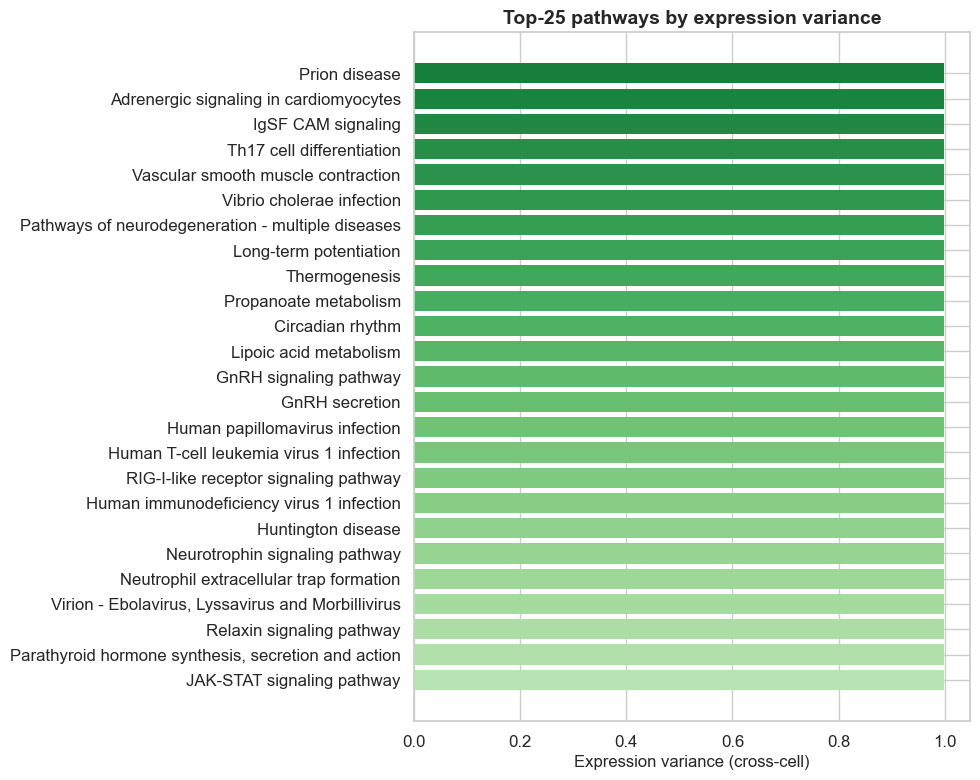

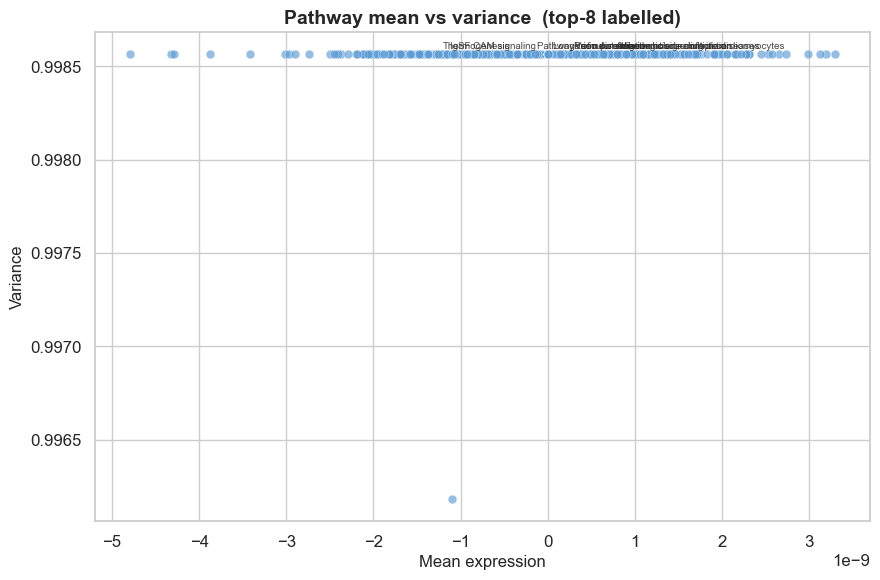

In [12]:
# ── 5b. Per-pathway mean expression across cell lines ─────────────────────
with open(ROOT / 'data/processed/pathway_gene_map.json') as f:
    pgm = json.load(f)

gene_cols = set(expr_matrix.columns)
pw_mean = {}
pw_var  = {}
for pw, genes in pgm.items():
    g_in = [g for g in genes if g in gene_cols]
    if g_in:
        vals = expr_matrix[g_in].values.ravel()
        pw_mean[pw] = vals.mean()
        pw_var[pw]  = vals.var()

pw_df = pd.DataFrame({'mean': pw_mean, 'var': pw_var}).sort_values('var', ascending=False)
print(f'Pathways with expression data: {len(pw_df)}')

# Top-25 pathways by expression variance
top25 = pw_df.head(25)['var'].sort_values()
colors_bar = plt.cm.Greens(np.linspace(0.30, 0.80, len(top25)))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top25.index, top25.values, color=colors_bar, edgecolor='none')
ax.set_xlabel('Expression variance (cross-cell)', fontsize=12)
ax.set_title('Top-25 pathways by expression variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Pathway mean vs variance scatter
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(pw_df['mean'], pw_df['var'], alpha=0.65, s=40, color='#5B9BD5',
           edgecolors='white', linewidths=0.4)
for pw_name in pw_df.head(8).index:
    ax.annotate(pw_name, (pw_df.loc[pw_name, 'mean'], pw_df.loc[pw_name, 'var']),
                fontsize=7, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Mean expression', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('Pathway mean vs variance  (top-8 labelled)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


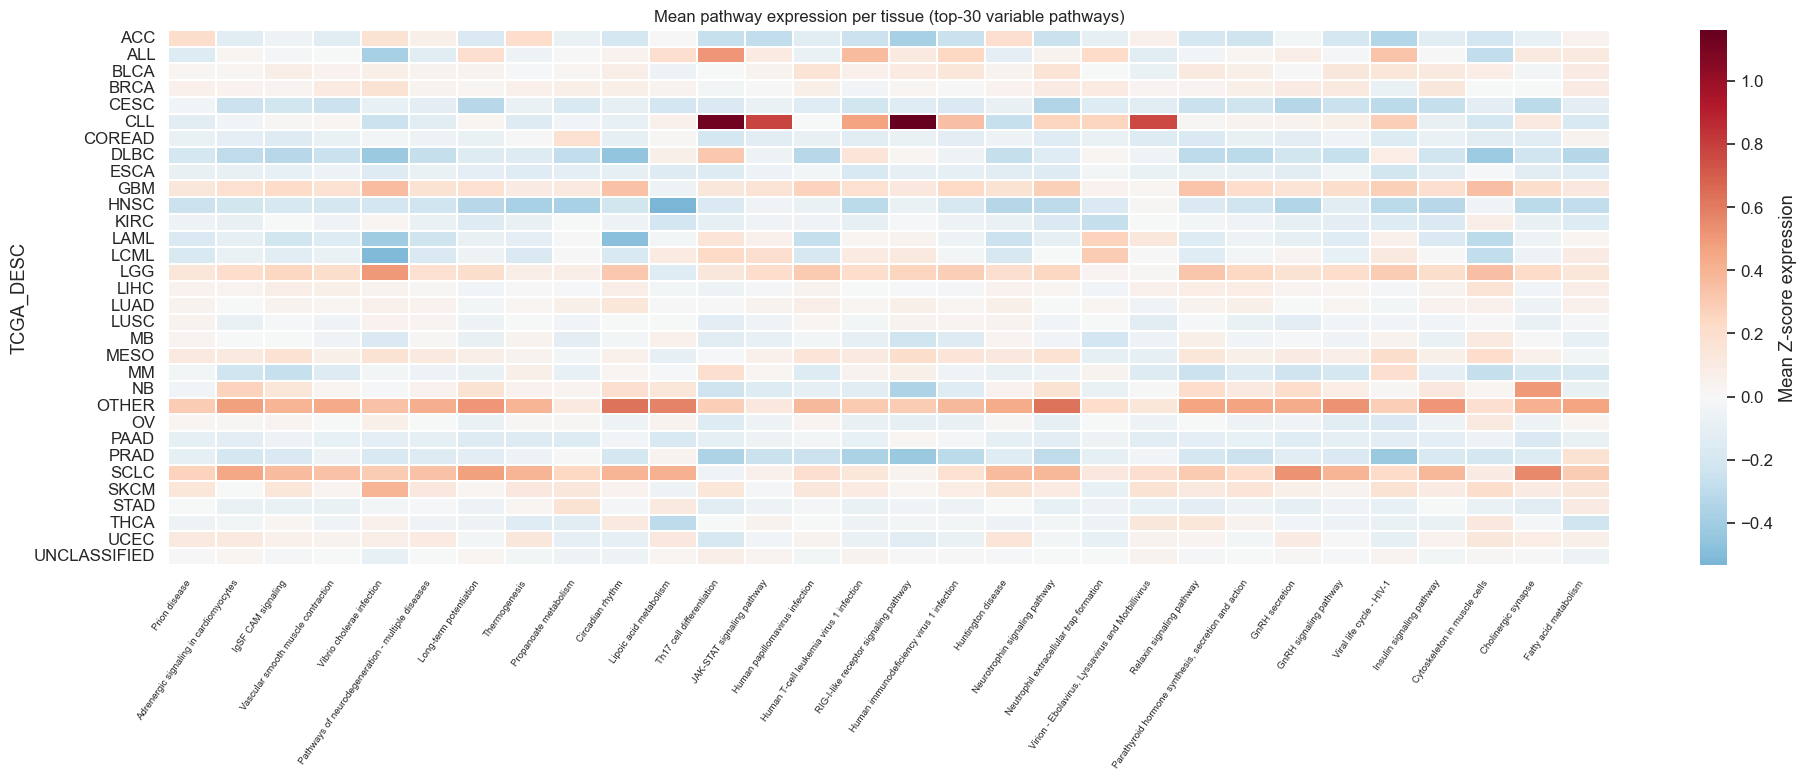

In [13]:
# ── 5c. Pathway-level expression heatmap (per tissue) ─────────────────────
# For each pathway, compute mean expression per TCGA tissue

# Map COSMIC_ID -> TCGA_DESC
cosmic_tissue = df[['COSMIC_ID','TCGA_DESC']].drop_duplicates('COSMIC_ID').set_index('COSMIC_ID')

# Build per-tissue mean expression matrix over top-30 variable pathways
top_pw = pw_df.head(30).index.tolist()

rows = []
for pw in top_pw:
    g_in = [g for g in pgm[pw] if g in gene_cols]
    if not g_in: continue
    pw_expr = expr_matrix[g_in].mean(axis=1)   # (n_cells,)
    pw_expr.index = pd.Index(expr_matrix.index, name='COSMIC_ID')
    pw_s = pw_expr.reset_index()
    pw_s.columns = ['COSMIC_ID', 'expr']
    pw_s = pw_s.merge(cosmic_tissue, on='COSMIC_ID', how='left')
    tissue_mean = pw_s.groupby('TCGA_DESC')['expr'].mean()
    rows.append(tissue_mean.rename(pw))

heat_df = pd.DataFrame(rows).T   # (tissues, pathways)
heat_df = heat_df.dropna(how='all').fillna(0)
heat_df = heat_df.loc[~(heat_df.index == 'nan')]

fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(heat_df, cmap='RdBu_r', center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={'label': 'Mean Z-score expression'})
ax.set_title('Mean pathway expression per tissue (top-30 variable pathways)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

---
## Part D — Dimensionality Reduction of Cell-Line Expression Space

We embed each cell line's gene expression into 2D using **t-SNE** and **UMAP**, then optimise their hyperparameters with **Particle Swarm Optimisation (PSO)** to maximise the silhouette score over tissue-type labels.

**Why PSO?** The t-SNE/UMAP loss surfaces are multimodal; PSO is derivative-free and parallelisable, making it well-suited for exploring perplexity/n_neighbors/min_dist jointly.

In [14]:
# ── 6a. Prepare cell-line feature matrix ──────────────────────────────────
# Use the PathwaySetEncoder's exact features: [mean, std] per pathway per cell
# This is what the model actually sees, so DR on this space is most informative.

cell_ids = expr_matrix.index.tolist()   # COSMIC_IDs as integers

pathway_names = sorted(pgm.keys())
n_pathways = len(pathway_names)
gene_list  = list(expr_matrix.columns)
gene_to_idx = {g: i for i, g in enumerate(gene_list)}
expr_np = expr_matrix.values.astype('float32')  # (n_cells, n_genes)

print(f'Building [{n_pathways} × 2] pathway features for {len(cell_ids)} cell lines...')

pw_features = np.zeros((len(cell_ids), n_pathways * 2), dtype='float32')
for p_idx, pname in enumerate(pathway_names):
    g_idx = [gene_to_idx[g] for g in pgm[pname] if g in gene_to_idx]
    if not g_idx:
        continue
    sub = expr_np[:, g_idx]
    pw_features[:, p_idx * 2]     = sub.mean(axis=1)
    pw_features[:, p_idx * 2 + 1] = sub.std(axis=1)

print(f'Pathway feature matrix: {pw_features.shape}  (cells × 2*pathways)')

# Attach tissue labels
cid_to_tissue = cosmic_tissue['TCGA_DESC'].to_dict()
tissue_labels = np.array([cid_to_tissue.get(int(c), 'UNKNOWN') for c in cell_ids])
unique_tissues = [t for t in np.unique(tissue_labels) if t != 'UNKNOWN']
tissue_to_int  = {t: i for i, t in enumerate(unique_tissues)}
label_int = np.array([tissue_to_int.get(t, -1) for t in tissue_labels])

# Keep only cells with known tissue for silhouette scoring
valid_mask = label_int >= 0
X_valid = pw_features[valid_mask]
y_valid = label_int[valid_mask]
print(f'Cells with known tissue: {valid_mask.sum()} / {len(cell_ids)}')

# Pre-reduce to 50 PCs for speed (standard t-SNE practice)
pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_valid)
print(f'PCA variance explained (50 PCs): {pca.explained_variance_ratio_.sum():.1%}')

Building [370 × 2] pathway features for 697 cell lines...
Pathway feature matrix: (697, 740)  (cells × 2*pathways)
Cells with known tissue: 697 / 697
PCA variance explained (50 PCs): 84.4%


In [15]:
# ── 6b. Particle Swarm Optimisation helpers ────────────────────────────────
#
# PSO minimises  -silhouette_score(embedding, tissue_labels)
# over the continuous hyperparameter space of t-SNE and UMAP.
#
# Particle representation:
#   t-SNE: [perplexity (5–100), learning_rate (10–1000), early_exaggeration (4–24)]
#   UMAP:  [n_neighbors (5–100), min_dist (0.001–0.9), spread (0.5–3.0)]

def clip_particle(pos, bounds):
    return np.clip(pos, bounds[:, 0], bounds[:, 1])

def pso(objective_fn, bounds, n_particles=15, n_iter=20, w=0.7, c1=1.5, c2=1.5, seed=SEED):
    """
    Simple PSO.
    bounds: (n_dims, 2) array of [lo, hi] per dimension.
    Returns (best_position, best_score, history)
    """
    rng = np.random.default_rng(seed)
    n_dims = bounds.shape[0]

    # Initialise
    pos = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_particles, n_dims))
    vel = rng.uniform(-(bounds[:, 1] - bounds[:, 0]),
                       (bounds[:, 1] - bounds[:, 0]),
                       size=(n_particles, n_dims)) * 0.1
    pbest_pos   = pos.copy()
    pbest_score = np.full(n_particles, np.inf)
    gbest_pos   = pos[0].copy()
    gbest_score = np.inf
    history     = []

    for it in range(n_iter):
        for i in range(n_particles):
            score = objective_fn(pos[i])
            if score < pbest_score[i]:
                pbest_score[i] = score
                pbest_pos[i]   = pos[i].copy()
            if score < gbest_score:
                gbest_score = score
                gbest_pos   = pos[i].copy()

        r1 = rng.random((n_particles, n_dims))
        r2 = rng.random((n_particles, n_dims))
        vel  = w * vel + c1 * r1 * (pbest_pos - pos) + c2 * r2 * (gbest_pos - pos)
        pos  = clip_particle(pos + vel, bounds)

        history.append(-gbest_score)
        print(f'  iter {it+1:2d}/{n_iter}  best_silhouette={-gbest_score:.4f}  params={gbest_pos}', flush=True)

    return gbest_pos, -gbest_score, history

print('PSO utility defined.')

PSO utility defined.


In [16]:
# ── 6c. Optimise t-SNE hyperparameters via PSO ────────────────────────────
import sklearn
_TSNE_ITER_KW = 'max_iter' if tuple(int(x) for x in sklearn.__version__.split('.')[:2]) >= (1, 5) else 'n_iter'

TSNE_BOUNDS = np.array([
    [5,   100],    # perplexity
    [10,  1000],   # learning_rate
    [4,   24],     # early_exaggeration
], dtype=float)

def tsne_objective(params):
    perp, lr, ee = params
    try:
        emb = TSNE(
            n_components=2,
            perplexity=float(perp),
            learning_rate=float(lr),
            early_exaggeration=float(ee),
            random_state=SEED,
            n_jobs=-1,
            **{_TSNE_ITER_KW: 500},
        ).fit_transform(X_pca)
        sc = silhouette_score(emb, y_valid, sample_size=500, random_state=SEED)
        return -sc
    except Exception:
        return 0.0   # penalise failures

print(f'sklearn {sklearn.__version__}  →  using TSNE kwarg: {_TSNE_ITER_KW}=500')
print('Running PSO for t-SNE  (15 particles × 15 iterations)...')
t0 = time.time()
tsne_best_params, tsne_best_sil, tsne_history = pso(
    tsne_objective, TSNE_BOUNDS, n_particles=15, n_iter=15, seed=SEED
)
print(f'\nt-SNE PSO done in {time.time()-t0:.0f}s')
print(f'Best params  -> perplexity={tsne_best_params[0]:.1f}, lr={tsne_best_params[1]:.1f}, ee={tsne_best_params[2]:.1f}')
print(f'Best silhouette = {tsne_best_sil:.4f}')


sklearn 1.7.1  →  using TSNE kwarg: max_iter=500
Running PSO for t-SNE  (15 particles × 15 iterations)...


  iter  1/15  best_silhouette=-0.3409  params=[  9.16135775 162.74659715  17.66097906]
  iter  2/15  best_silhouette=-0.3401  params=[ 7.22859572 22.3203967   8.06440666]
  iter  3/15  best_silhouette=-0.3243  params=[ 5.         59.11601743  5.76397979]
  iter  4/15  best_silhouette=-0.3243  params=[ 5.         59.11601743  5.76397979]
  iter  5/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8.46479665]
  iter  6/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8.46479665]
  iter  7/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8.46479665]
  iter  8/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8.46479665]
  iter  9/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8.46479665]
  iter 10/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8.46479665]
  iter 11/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8.46479665]
  iter 12/15  best_silhouette=-0.3190  params=[ 5.         43.89401205  8

In [17]:
# ── 6d. Optimise UMAP hyperparameters via PSO ─────────────────────────────
UMAP_BOUNDS = np.array([
    [5,   100],    # n_neighbors
    [0.001, 0.5],  # min_dist  (cap at 0.5 so spread can always be >= min_dist)
    [0.5,  3.0],   # spread
], dtype=float)

def umap_objective(params):
    nn, md, sp = params
    md = float(md)
    sp = max(float(sp), md)   # enforce UMAP constraint: spread >= min_dist
    try:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=max(2, int(nn)),
            min_dist=md,
            spread=sp,
            random_state=SEED,
            low_memory=True,
        )
        emb = reducer.fit_transform(X_pca)
        sc = silhouette_score(emb, y_valid, sample_size=500, random_state=SEED)
        return -sc
    except Exception:
        return 0.0

print('Running PSO for UMAP  (15 particles × 15 iterations)...')
t0 = time.time()
umap_best_params, umap_best_sil, umap_history = pso(
    umap_objective, UMAP_BOUNDS, n_particles=15, n_iter=15, seed=SEED
)
print(f'\nUMAP PSO done in {time.time()-t0:.0f}s')
print(f'Best params  -> n_neighbors={umap_best_params[0]:.1f}, min_dist={umap_best_params[1]:.4f}, spread={umap_best_params[2]:.3f}')
print(f'Best silhouette = {umap_best_sil:.4f}')


Running PSO for UMAP  (15 particles × 15 iterations)...
  iter  1/15  best_silhouette=-0.3587  params=[17.34254301  0.23837676  1.06727337]
  iter  2/15  best_silhouette=-0.3357  params=[5.         0.24222271 0.88162691]
  iter  3/15  best_silhouette=-0.3353  params=[5.         0.18517619 0.69656625]
  iter  4/15  best_silhouette=-0.3353  params=[5.         0.18517619 0.69656625]
  iter  5/15  best_silhouette=-0.3327  params=[5.         0.33068152 0.5       ]
  iter  6/15  best_silhouette=-0.3262  params=[5.         0.22326458 0.5       ]
  iter  7/15  best_silhouette=-0.3262  params=[5.         0.22326458 0.5       ]
  iter  8/15  best_silhouette=-0.3262  params=[5.         0.22326458 0.5       ]
  iter  9/15  best_silhouette=-0.3262  params=[5.         0.22326458 0.5       ]
  iter 10/15  best_silhouette=-0.3262  params=[5.         0.22326458 0.5       ]
  iter 11/15  best_silhouette=-0.3262  params=[5.         0.22326458 0.5       ]
  iter 12/15  best_silhouette=-0.3262  params=[5. 

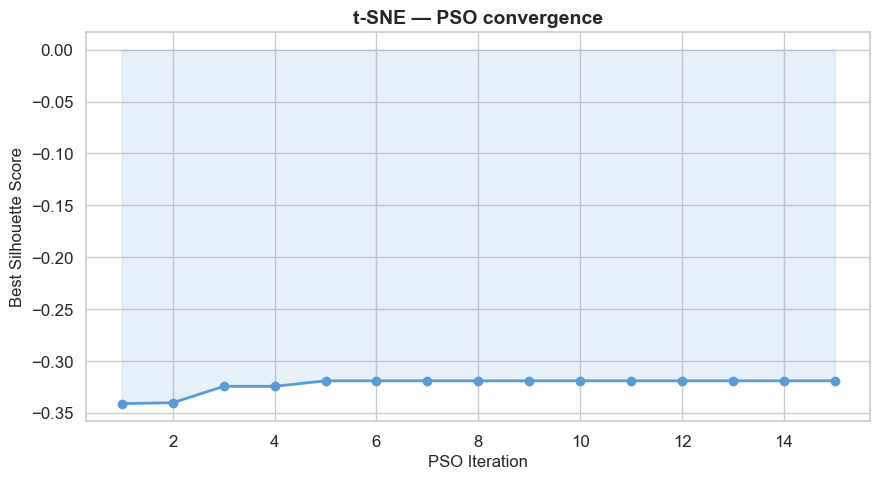

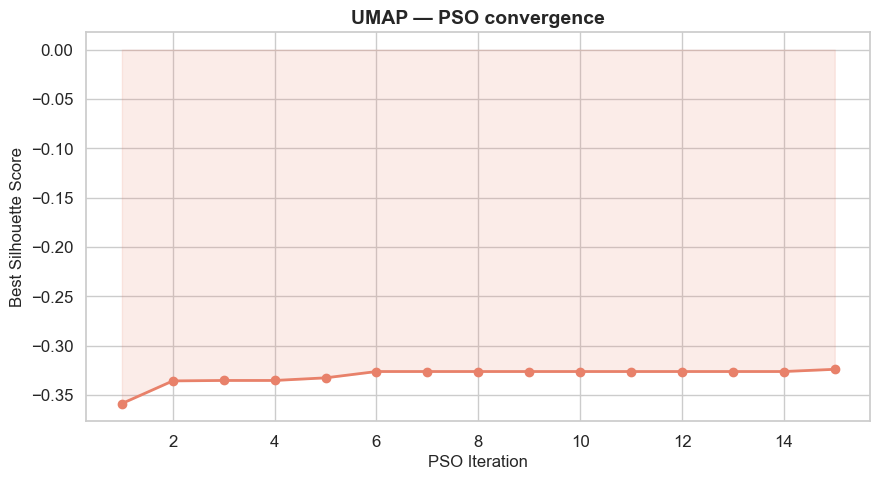

In [18]:
# ── 6e. PSO convergence — t-SNE ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(tsne_history) + 1), tsne_history,
        marker='o', color='#5B9BD5', linewidth=2, markersize=6)
ax.fill_between(range(1, len(tsne_history) + 1), tsne_history, alpha=0.15, color='#5B9BD5')
ax.set_xlabel('PSO Iteration', fontsize=12)
ax.set_ylabel('Best Silhouette Score', fontsize=12)
ax.set_title('t-SNE — PSO convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6e. PSO convergence — UMAP ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(umap_history) + 1), umap_history,
        marker='o', color='#E8816A', linewidth=2, markersize=6)
ax.fill_between(range(1, len(umap_history) + 1), umap_history, alpha=0.15, color='#E8816A')
ax.set_xlabel('PSO Iteration', fontsize=12)
ax.set_ylabel('Best Silhouette Score', fontsize=12)
ax.set_title('UMAP — PSO convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Part E — Visualisations with Optimal Embeddings

In [19]:
# ── 7a. Final embeddings with optimised params ────────────────────────────
print('Computing final t-SNE with best params...')
tsne_final = TSNE(
    n_components=2,
    perplexity=float(tsne_best_params[0]),
    learning_rate=float(tsne_best_params[1]),
    early_exaggeration=float(tsne_best_params[2]),
    random_state=SEED,
    n_jobs=-1,
    **{_TSNE_ITER_KW: 1000},
).fit_transform(X_pca)

print('Computing final UMAP with best params...')
_md = float(umap_best_params[1])
_sp = max(float(umap_best_params[2]), _md)   # enforce spread >= min_dist
umap_final = umap.UMAP(
    n_components=2,
    n_neighbors=max(2, int(umap_best_params[0])),
    min_dist=_md,
    spread=_sp,
    random_state=SEED,
).fit_transform(X_pca)

print('Done.')


Computing final t-SNE with best params...
Computing final UMAP with best params...
Done.


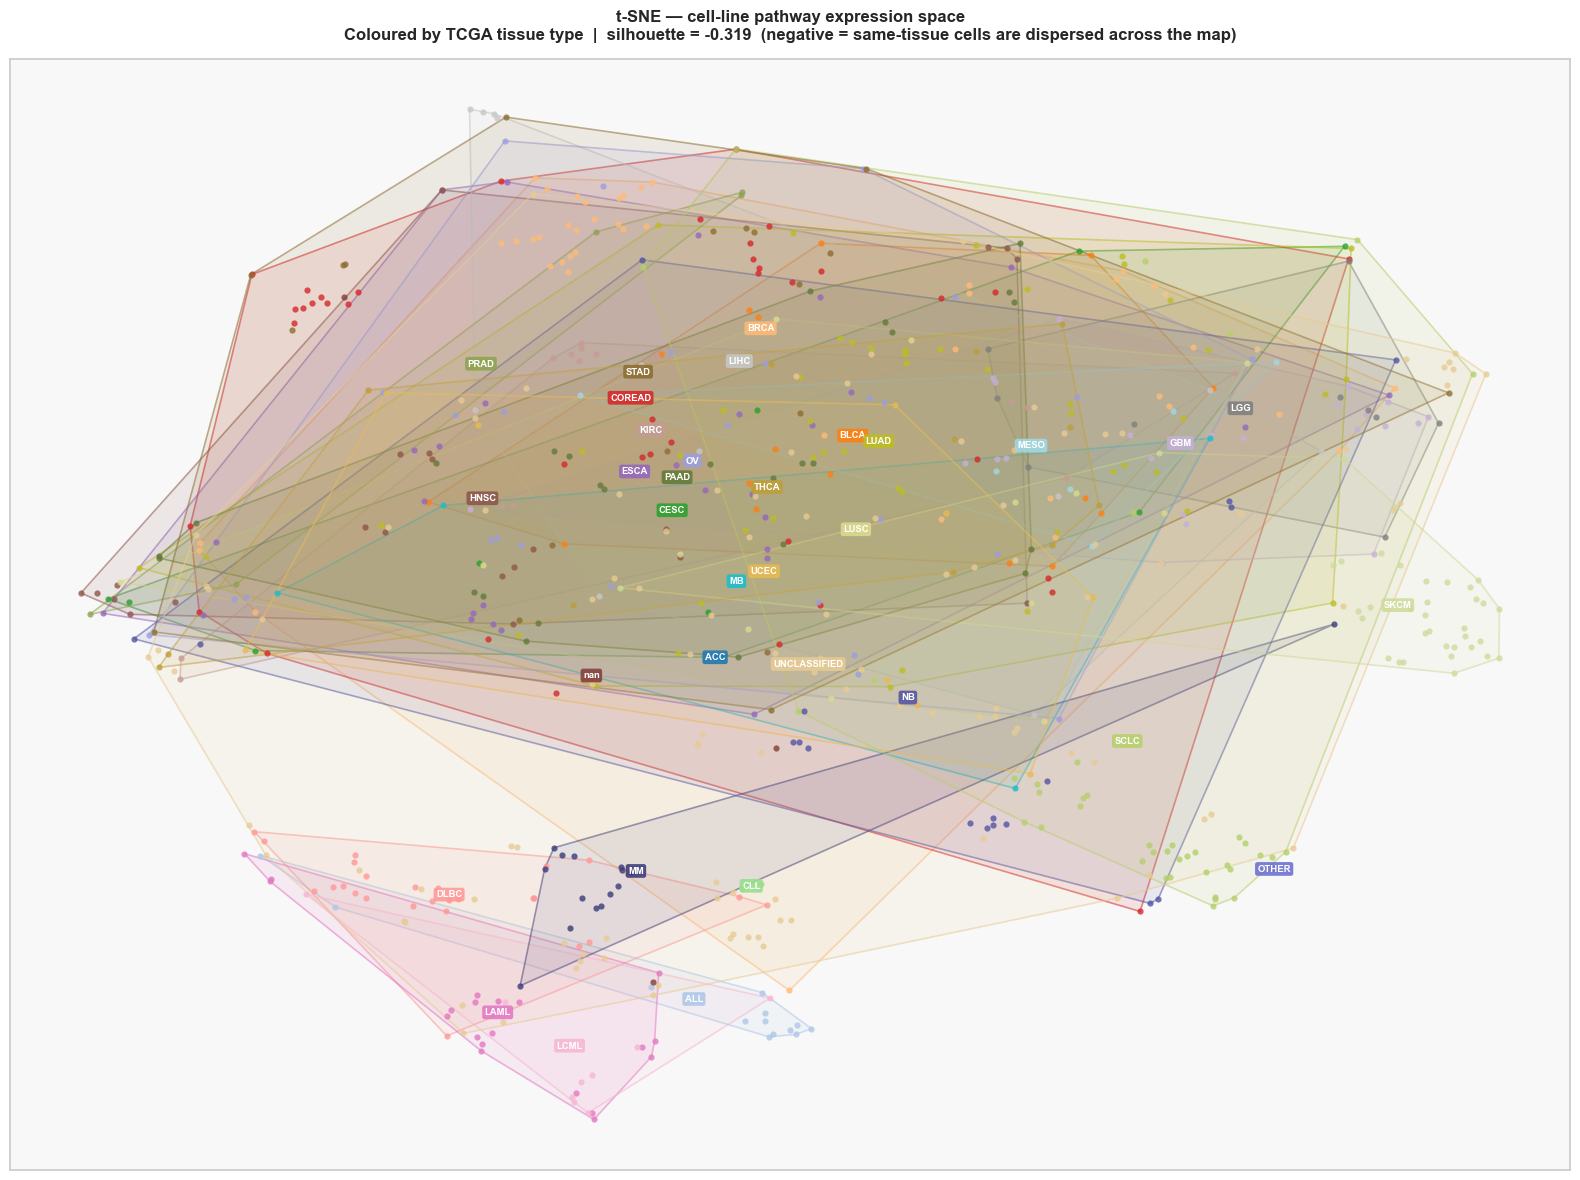

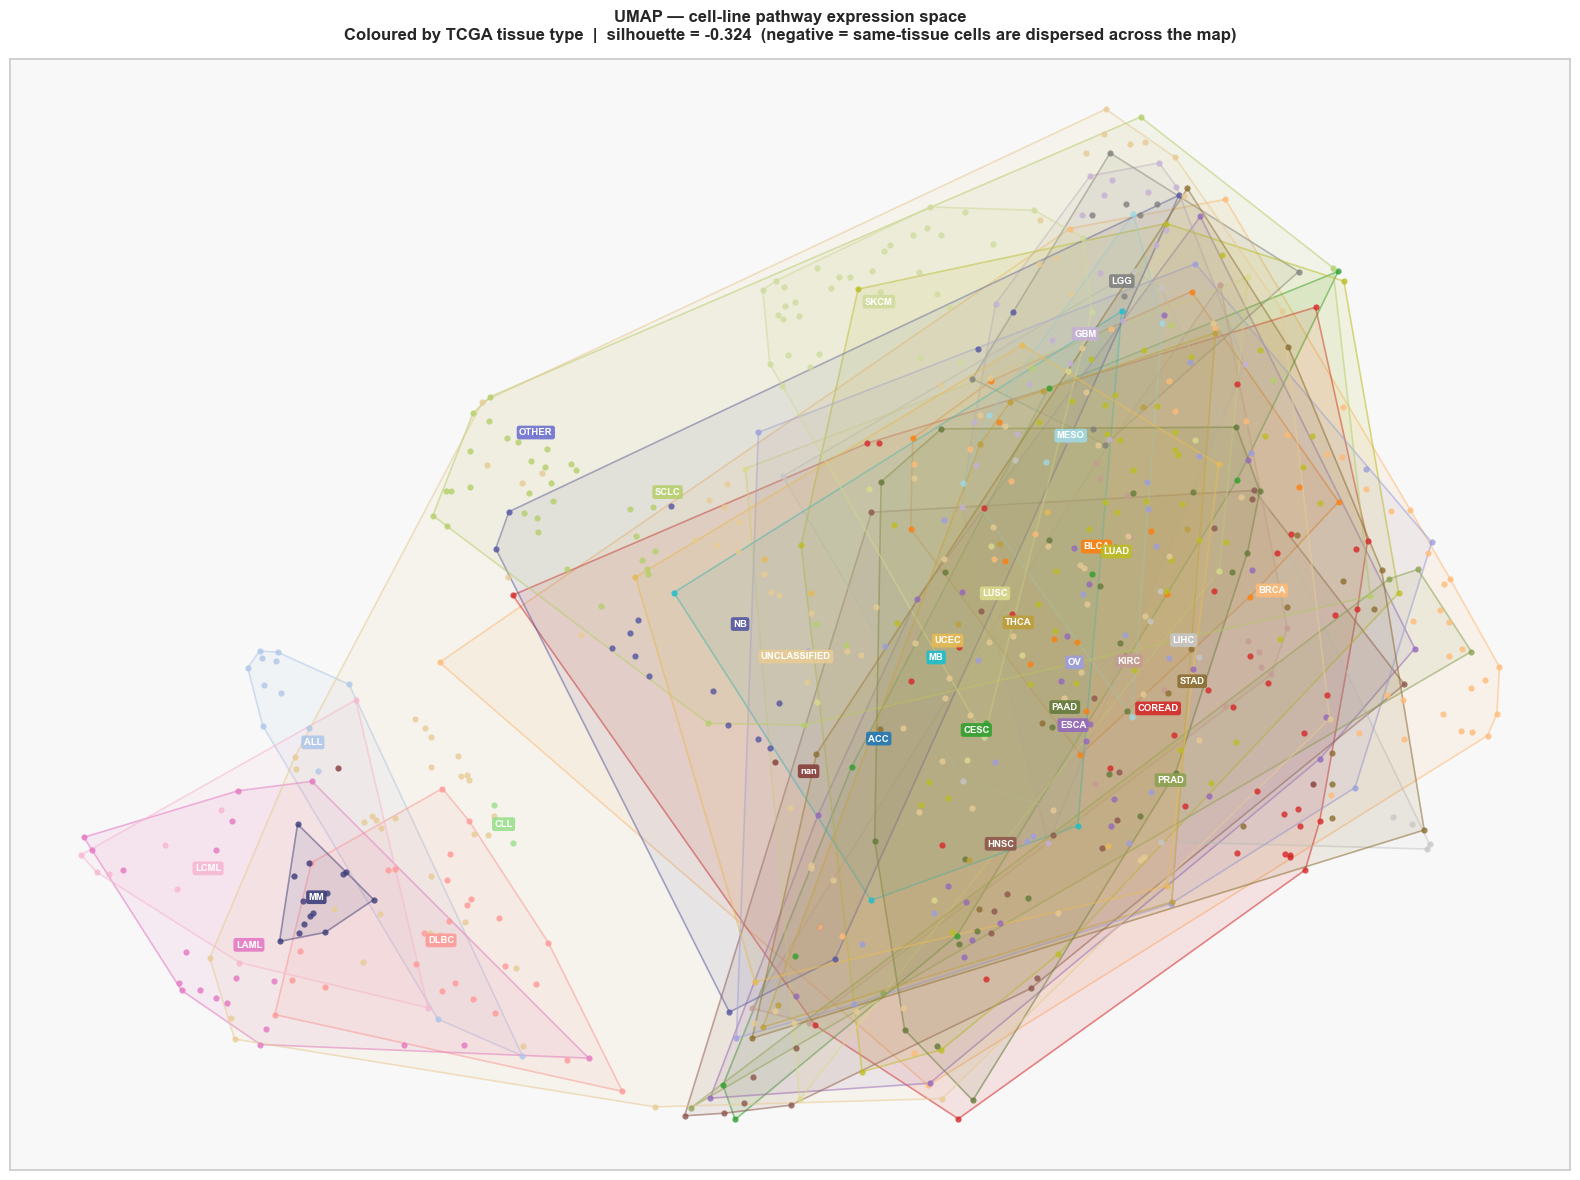

In [20]:
# ── 7b. Annotated tissue embeddings — convex hull boundaries + labels ─────
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

def plot_annotated_embedding(emb, labels, method_name, sil_score):
    """
    One figure per embedding method.
    - Shaded convex hull per tissue type shows the spatial territory
    - Tissue name labelled directly at the cluster centroid
    - No separate legend needed
    """
    unique_labels = sorted(set(labels))
    n = len(unique_labels)

    # Build a colour palette with enough distinct colours for 33 classes
    # Combine tab20 and tab20b to get 40 distinct colours
    c1 = [plt.cm.tab20(i)  for i in range(20)]
    c2 = [plt.cm.tab20b(i) for i in range(20)]
    all_colours = c1 + c2
    colour_map = {lab: all_colours[i % len(all_colours)] for i, lab in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_facecolor('#F8F8F8')
    fig.patch.set_facecolor('white')

    # ── 1. Draw convex hulls (filled + outlined) ───────────────────────────
    for lab in unique_labels:
        mask = labels == lab
        pts  = emb[mask]
        col  = colour_map[lab]
        rgba = list(col[:3]) + [0.10]   # very light fill
        edge = list(col[:3]) + [0.55]   # semi-transparent edge

        if pts.shape[0] >= 4:
            try:
                hull     = ConvexHull(pts)
                hull_pts = pts[hull.vertices]
                poly = Polygon(hull_pts, closed=True,
                               facecolor=rgba, edgecolor=edge,
                               linewidth=1.2, zorder=1)
                ax.add_patch(poly)
            except Exception:
                pass  # degenerate hull — skip silently

    # ── 2. Draw scatter points ─────────────────────────────────────────────
    for lab in unique_labels:
        mask = labels == lab
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[colour_map[lab]], s=20, alpha=0.80,
                   linewidths=0, zorder=2)

    # ── 3. Label each cluster at its centroid ─────────────────────────────
    for lab in unique_labels:
        mask = labels == lab
        cx = emb[mask, 0].mean()
        cy = emb[mask, 1].mean()
        col = colour_map[lab]
        ax.text(cx, cy, lab,
                fontsize=6.8, fontweight='bold',
                ha='center', va='center', zorder=3,
                color='white',
                bbox=dict(boxstyle='round,pad=0.25',
                          facecolor=col, alpha=0.88,
                          edgecolor='none'))

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(
        f'{method_name} — cell-line pathway expression space\n'
        f'Coloured by TCGA tissue type  |  '
        f'silhouette = {sil_score:+.3f}  '
        f'(negative = same-tissue cells are dispersed across the map)',
        fontsize=12, fontweight='bold', pad=14
    )
    plt.tight_layout()
    plt.show()


# One figure per method
plot_annotated_embedding(
    tsne_final,
    tissue_labels[valid_mask],
    't-SNE',
    tsne_best_sil
)

plot_annotated_embedding(
    umap_final,
    tissue_labels[valid_mask],
    'UMAP',
    umap_best_sil
)


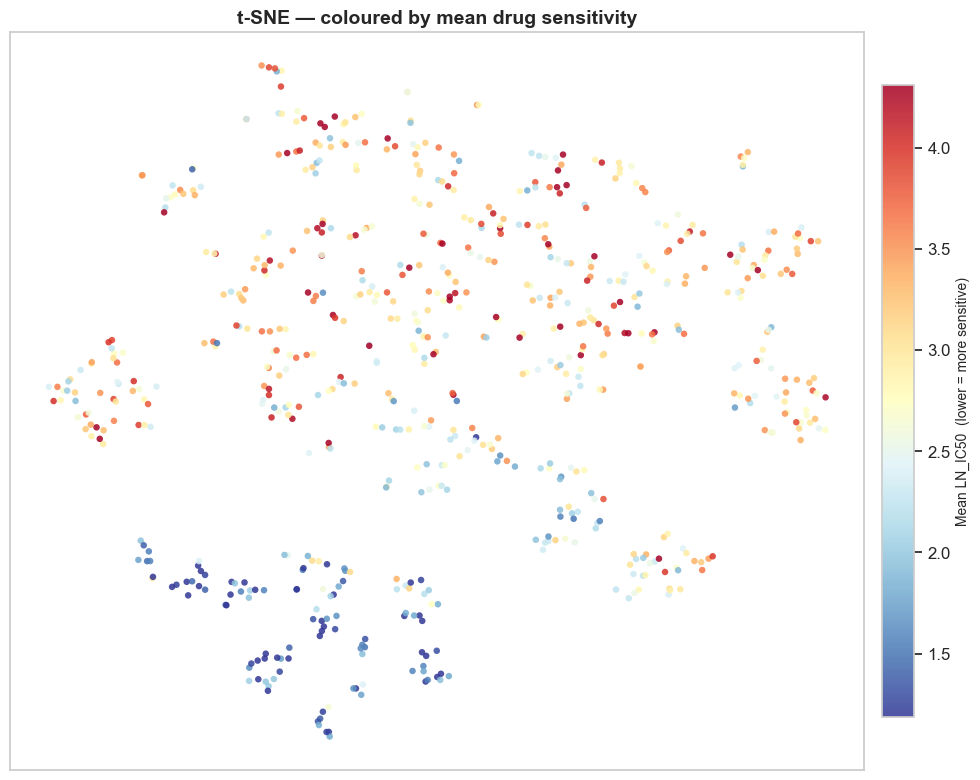

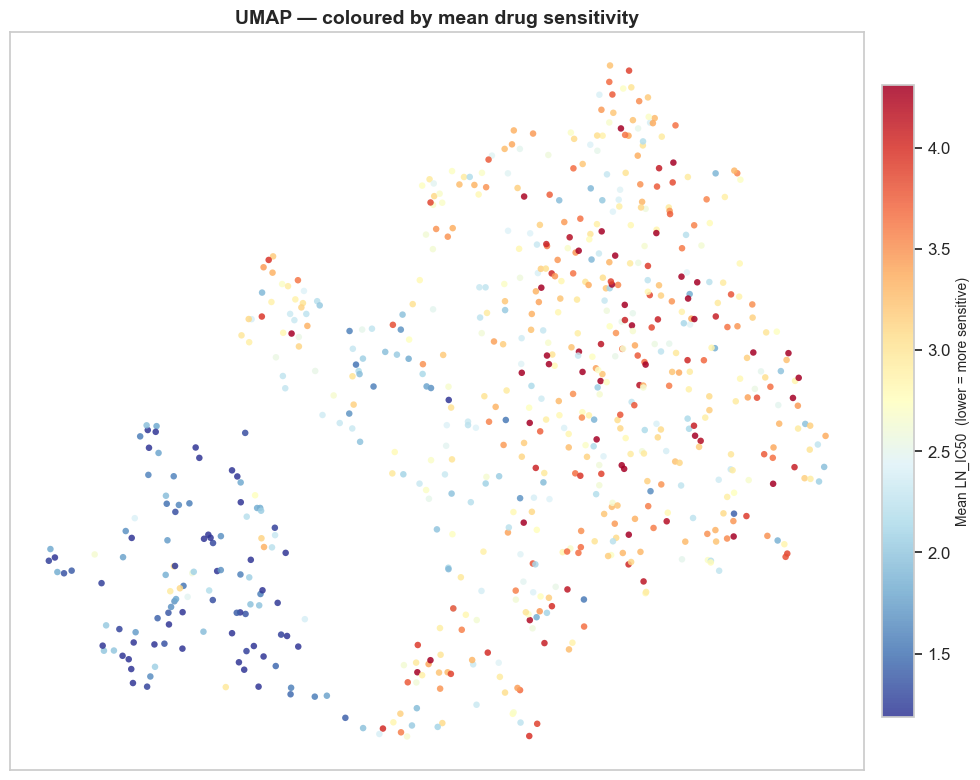

In [21]:
# ── 7c. Colour by mean drug sensitivity (mean LN_IC50 per cell line) ──────
mean_ic50 = df.groupby('COSMIC_ID')['LN_IC50'].mean()
valid_cell_ids = [int(c) for c, v in zip(cell_ids, valid_mask) if v]
sens = np.array([mean_ic50.get(c, np.nan) for c in valid_cell_ids])
vmin, vmax = np.nanpercentile(sens, 5), np.nanpercentile(sens, 95)

for emb, title in [(tsne_final, 't-SNE'), (umap_final, 'UMAP')]:
    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=sens, cmap='RdYlBu_r',
                    s=22, alpha=0.85, linewidths=0, vmin=vmin, vmax=vmax)
    cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label('Mean LN_IC50  (lower = more sensitive)', fontsize=10)
    ax.set_title(f'{title} — coloured by mean drug sensitivity', fontsize=14, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()


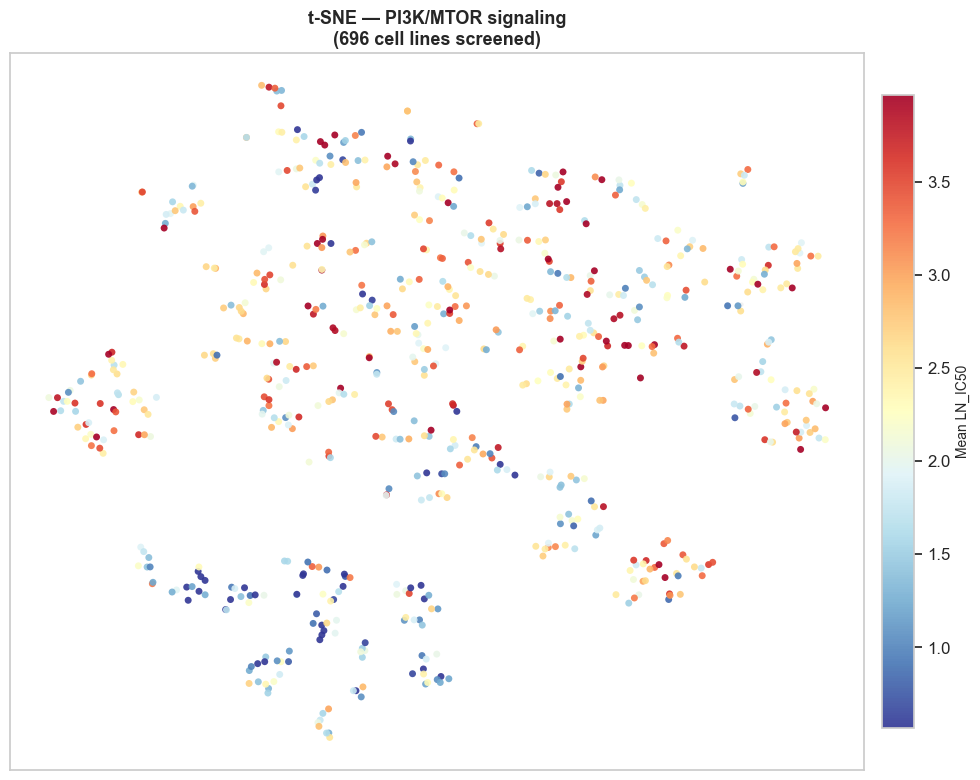

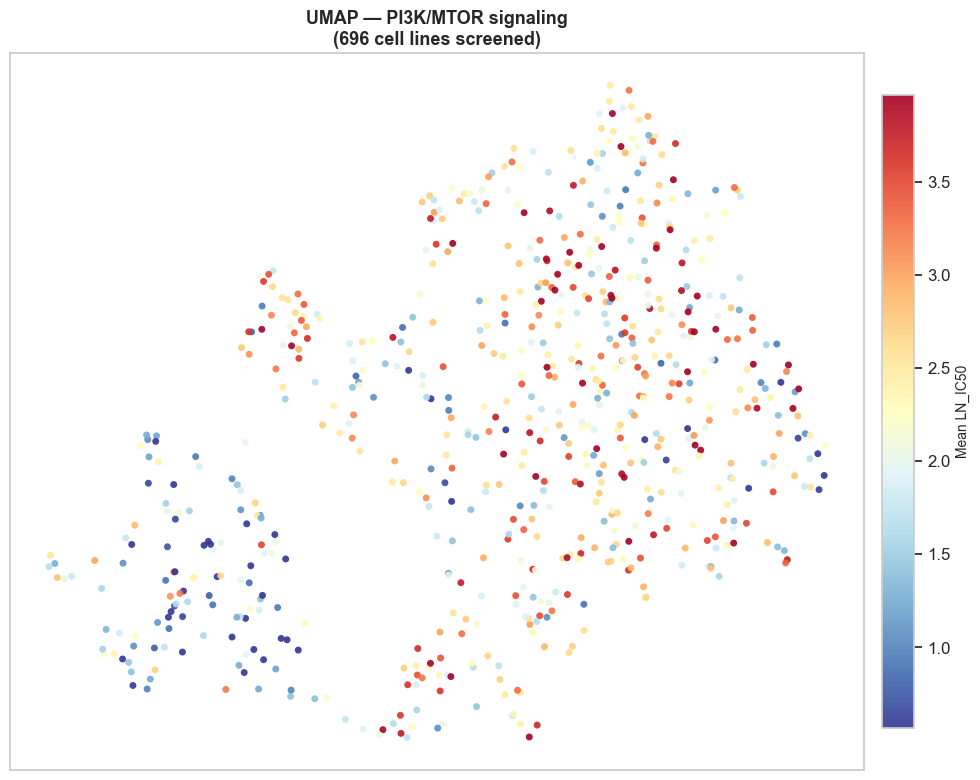

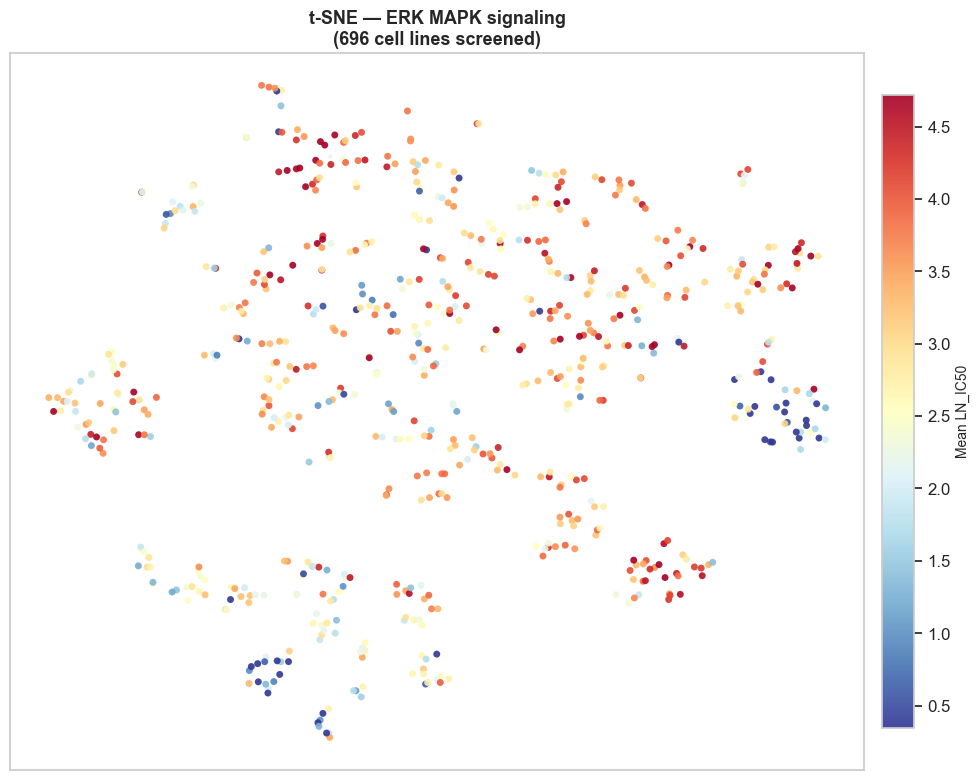

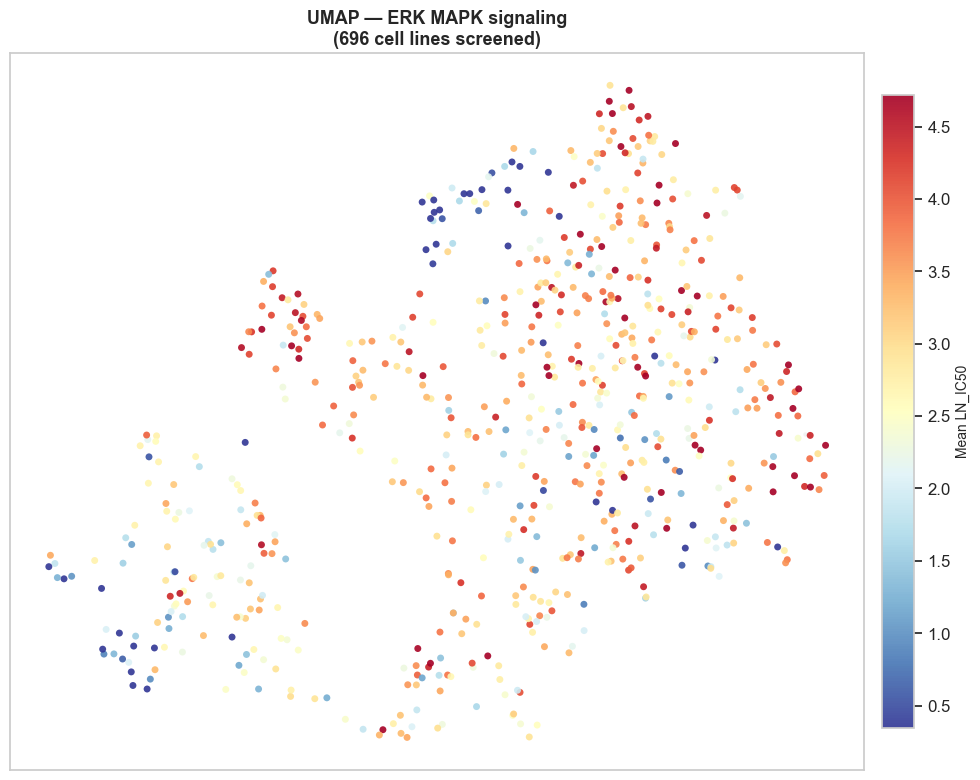

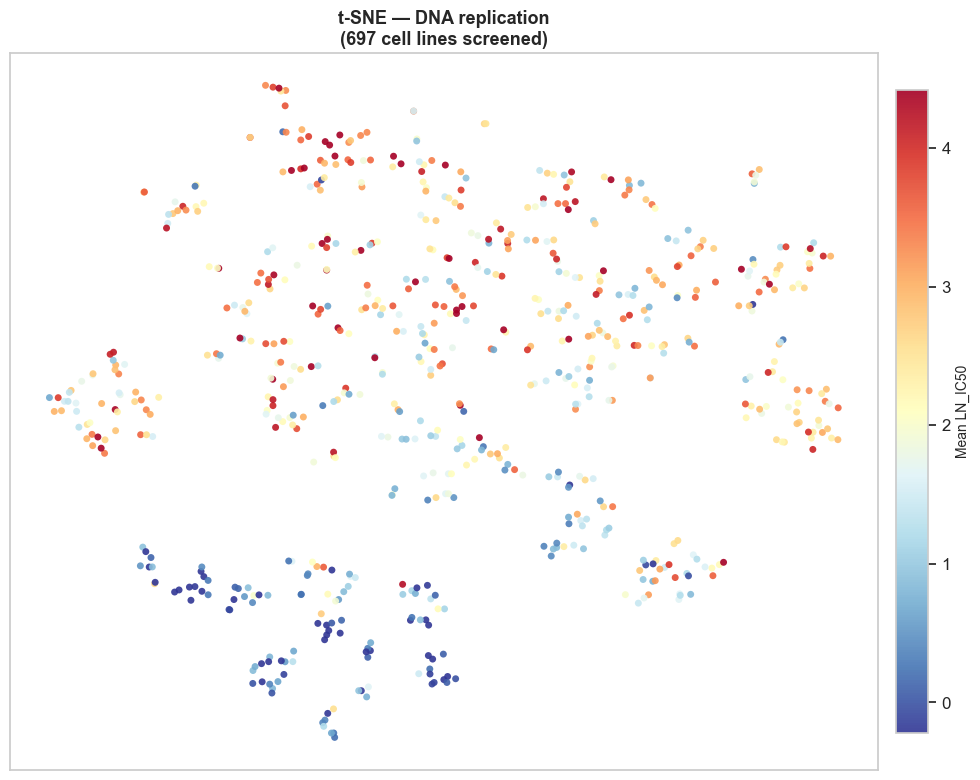

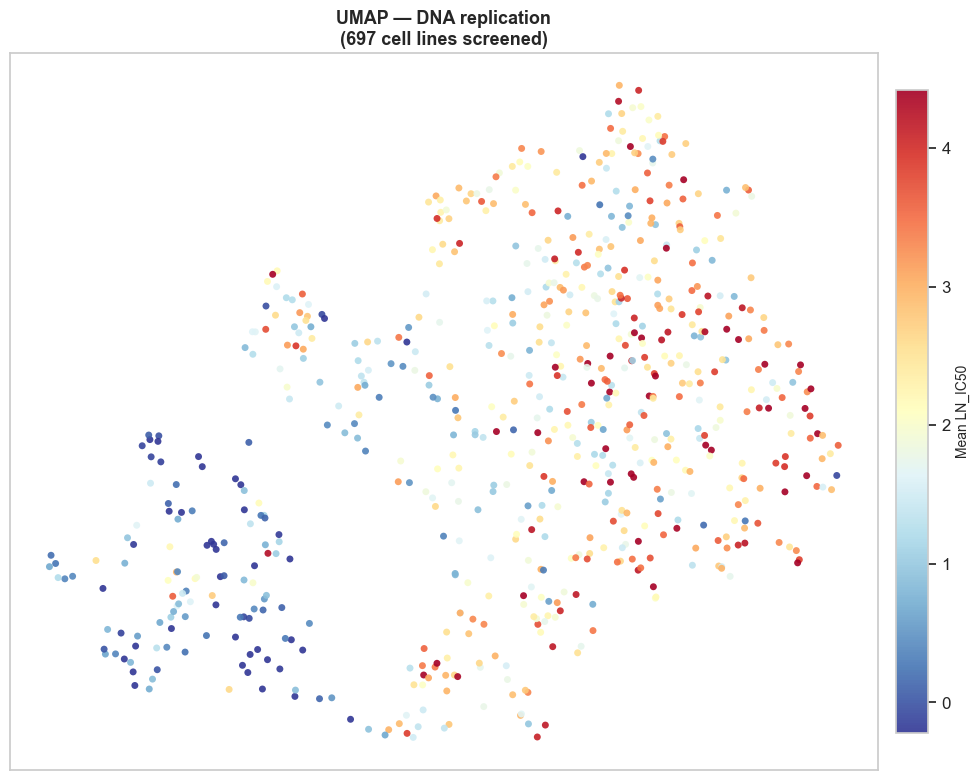

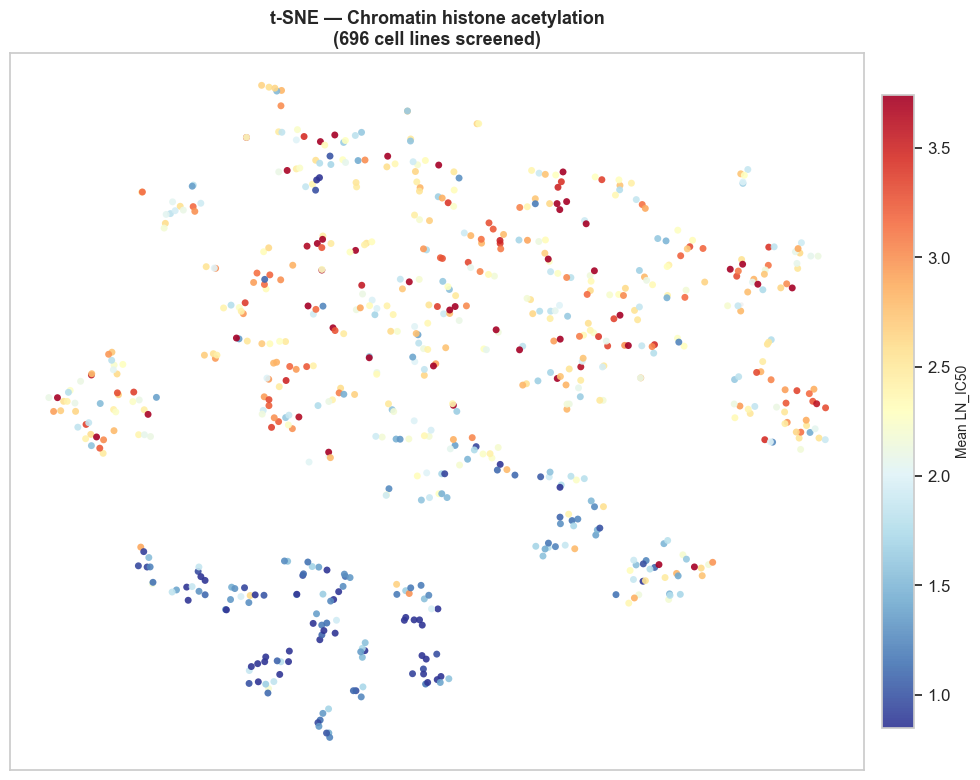

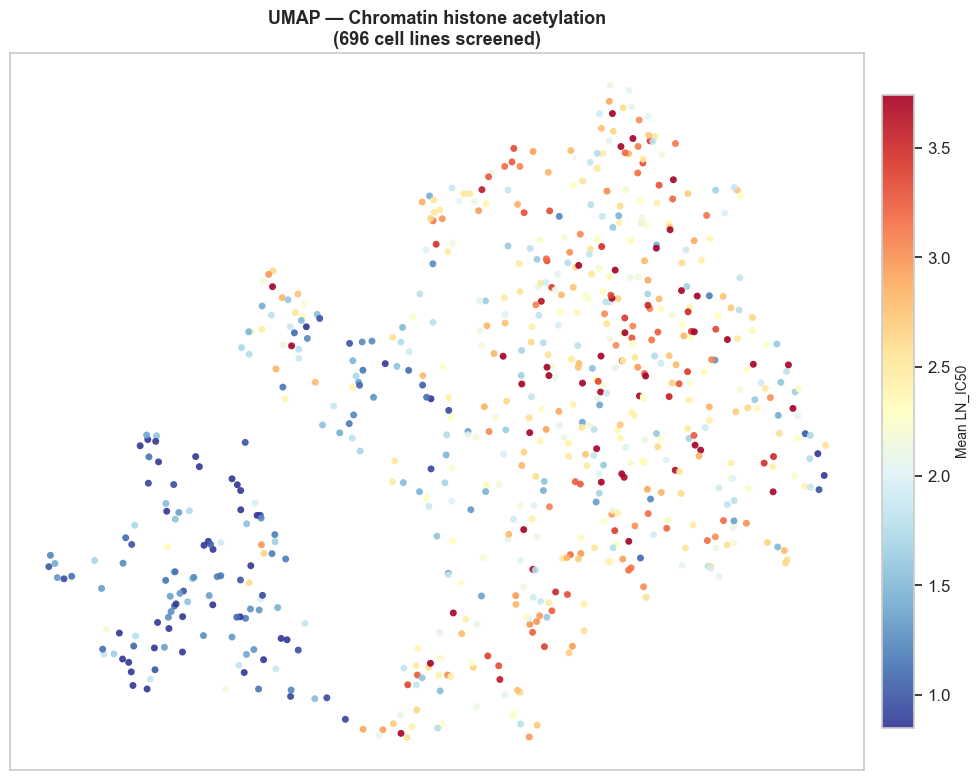

In [22]:
# ── 7d. Colour by sensitivity to specific drug pathways ───────────────────
# Each pathway gets its own figure; t-SNE and UMAP shown side-by-side per pathway.
select_pathways = ['PI3K/MTOR signaling', 'ERK MAPK signaling',
                   'DNA replication', 'Chromatin histone acetylation']

for pw in select_pathways:
    pw_ic50  = df[df['PATHWAY_NAME'] == pw].groupby('COSMIC_ID')['LN_IC50'].mean()
    pw_sens  = np.array([pw_ic50.get(c, np.nan) for c in valid_cell_ids])
    notnan   = ~np.isnan(pw_sens)
    vmin_pw  = np.nanpercentile(pw_sens, 5)
    vmax_pw  = np.nanpercentile(pw_sens, 95)
    n_screened = notnan.sum()

    for emb, method in [(tsne_final, 't-SNE'), (umap_final, 'UMAP')]:
        fig, ax = plt.subplots(figsize=(10, 8))
        # Grey background for cells not screened with this pathway
        ax.scatter(emb[~notnan, 0], emb[~notnan, 1],
                   c='#DCDCDC', s=10, alpha=0.35, linewidths=0, label='Not screened')
        sc = ax.scatter(emb[notnan, 0], emb[notnan, 1], c=pw_sens[notnan],
                        cmap='RdYlBu_r', s=25, alpha=0.90, linewidths=0,
                        vmin=vmin_pw, vmax=vmax_pw)
        cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
        cb.set_label('Mean LN_IC50', fontsize=10)
        ax.set_title(f'{method} — {pw}\n({n_screened} cell lines screened)',
                     fontsize=13, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout()
        plt.show()


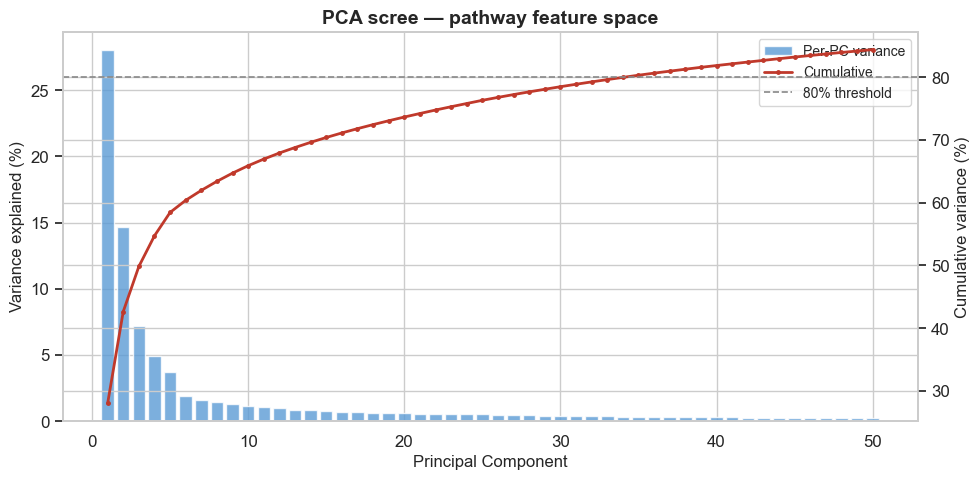

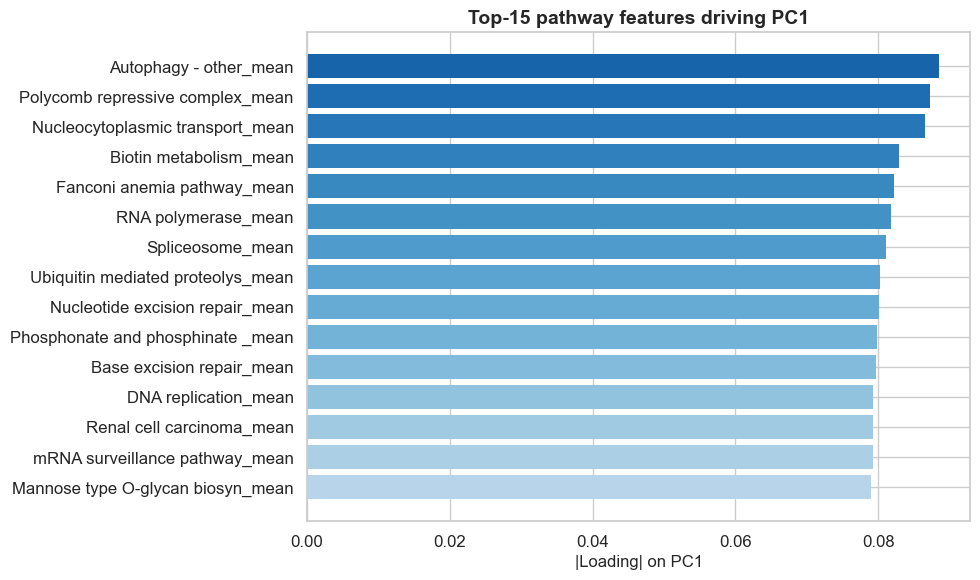

In [23]:
# ── 7e-i. PCA scree plot ──────────────────────────────────────────────────
ev = pca.explained_variance_ratio_
cum_ev = np.cumsum(ev) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(ev) + 1), ev * 100, color='#5B9BD5', alpha=0.80, label='Per-PC variance')
ax2 = ax.twinx()
ax2.plot(range(1, len(ev) + 1), cum_ev, color='#C0392B', linewidth=2,
         marker='.', markersize=5, label='Cumulative')
ax2.axhline(80, color='#888', linestyle='--', linewidth=1.2, label='80% threshold')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Variance explained (%)', fontsize=12)
ax2.set_ylabel('Cumulative variance (%)', fontsize=12)
ax.set_title('PCA scree — pathway feature space', fontsize=14, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
plt.tight_layout()
plt.show()

# ── 7e-ii. Top-15 pathway feature loadings on PC1 ────────────────────────
feature_names = []
for pw in pathway_names:
    feature_names += [f'{pw[:28]}_mean', f'{pw[:28]}_std']

pc1_load = pd.Series(pca.components_[0], index=feature_names).abs().nlargest(15).sort_values()
colors_bar = plt.cm.Blues(np.linspace(0.30, 0.80, len(pc1_load)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pc1_load.index, pc1_load.values, color=colors_bar, edgecolor='none')
ax.set_xlabel('|Loading| on PC1', fontsize=12)
ax.set_title('Top-15 pathway features driving PC1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Part F — Methodology Implications

Summarise what the embeddings suggest about model design.

PCA (50D)       silhouette=-0.1736   5NN balanced-acc=0.3449
t-SNE           silhouette=-0.3171   5NN balanced-acc=0.3014
UMAP            silhouette=-0.3240   5NN balanced-acc=0.2651

            Silhouette  5-NN Balanced Acc
PCA (50D)     -0.1736             0.3449
t-SNE         -0.3171             0.3014
UMAP          -0.3240             0.2651


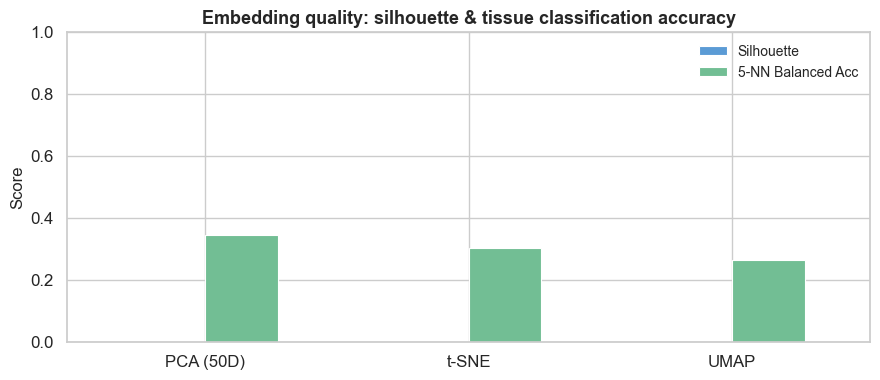

In [24]:
# ── 8. Quantify cluster quality across methods ────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

results_summary = {}
for name, emb in [('PCA (50D)', X_pca), ('t-SNE', tsne_final), ('UMAP', umap_final)]:
    sil = silhouette_score(emb, y_valid, sample_size=500, random_state=SEED)
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    acc = cross_val_score(knn, emb, y_valid, cv=5, scoring='balanced_accuracy').mean()
    results_summary[name] = {'Silhouette': round(sil, 4), '5-NN Balanced Acc': round(acc, 4)}
    print(f'{name:<14}  silhouette={sil:.4f}   5NN balanced-acc={acc:.4f}')

summary_df = pd.DataFrame(results_summary).T
print('\n', summary_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
summary_df.plot(kind='bar', ax=ax, rot=0,
                color=['#5B9BD5', '#72BE94'], edgecolor='white', linewidth=0.8, width=0.55)
ax.set_ylim(0, 1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Embedding quality: silhouette & tissue classification accuracy',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()


In [27]:
# ── 9. Correlate embedding spread with model prediction error ─────────────
mae_r, mae_p = None, None   # default: no predictions available

preds_path = ROOT / 'results/pathxdrp/random_seed0_fold0_preds.csv'
if preds_path.exists():
    preds_df = pd.read_csv(preds_path)
    preds_df['abs_err'] = (preds_df['y_true'] - preds_df['y_pred']).abs()

    cell_mae = preds_df.groupby('cosmic_id')['abs_err'].mean()

    umap_df = pd.DataFrame(umap_final, columns=['u1', 'u2'])
    umap_df['COSMIC_ID'] = valid_cell_ids
    umap_df['MAE'] = umap_df['COSMIC_ID'].map(cell_mae)
    umap_df = umap_df.dropna(subset=['MAE'])

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(umap_df['u1'], umap_df['u2'], c=umap_df['MAE'],
                    cmap='YlOrRd', s=25, alpha=0.85, linewidths=0)
    cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label('PathXDRP MAE  (higher = worse prediction)', fontsize=10)
    ax.set_title('UMAP embedding — PathXDRP prediction error per cell line',
                 fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

    centroid = umap_df[['u1', 'u2']].values.mean(axis=0)
    umap_df['dist_from_centroid'] = np.linalg.norm(
        umap_df[['u1', 'u2']].values - centroid, axis=1
    )
    mae_r, mae_p = stats.pearsonr(umap_df['dist_from_centroid'], umap_df['MAE'])
    print(f'Pearson r (UMAP distance vs MAE):  r={mae_r:.4f}  p={mae_p:.4f}')
else:
    print('PathXDRP predictions not found — run the model first.')
    print('mae_r and mae_p set to None; diagnostic cell will skip this section.')


PathXDRP predictions not found — run the model first.
mae_r and mae_p set to None; diagnostic cell will skip this section.


In [28]:
# ── 10. Automated diagnostic — plain-English interpretation ───────────────
n_tissue_classes = len(unique_tissues)
random_baseline   = 1.0 / n_tissue_classes

pca_sil  = results_summary['PCA (50D)']['Silhouette']
tsne_sil = results_summary['t-SNE']['Silhouette']
umap_sil = results_summary['UMAP']['Silhouette']
pca_acc  = results_summary['PCA (50D)']['5-NN Balanced Acc']
tsne_acc = results_summary['t-SNE']['5-NN Balanced Acc']
umap_acc = results_summary['UMAP']['5-NN Balanced Acc']

# mae_r / mae_p come from cell 9 (None if predictions file was absent)

print('=' * 72)
print('  EMBEDDING DIAGNOSTIC REPORT')
print('=' * 72)

print(f'''
DATASET
  {len(valid_cell_ids):,} cell lines  |  {n_tissue_classes} TCGA tissue types
  Random-guess tissue accuracy = {random_baseline:.1%}

DO TISSUE TYPES CLUSTER IN PATHWAY EXPRESSION SPACE?
  Silhouette scores (−1 worst → 0 overlapping → +1 perfect clusters):
    PCA  : {pca_sil:+.3f}   {"negative → same-tissue cells are MORE spread out than chance" if pca_sil < 0 else "positive → some tissue clustering"}
    t-SNE: {tsne_sil:+.3f}   {"negative → same-tissue cells are MORE spread out than chance" if tsne_sil < 0 else "positive → some tissue clustering"}
    UMAP : {umap_sil:+.3f}   {"negative → same-tissue cells are MORE spread out than chance" if umap_sil < 0 else "positive → some tissue clustering"}

  5-NN tissue classification balanced accuracy:
    PCA  : {pca_acc:.1%}  (random = {random_baseline:.1%}, lift = {pca_acc / random_baseline:.1f}×)
    t-SNE: {tsne_acc:.1%}  (random = {random_baseline:.1%}, lift = {tsne_acc / random_baseline:.1f}×)
    UMAP : {umap_acc:.1%}  (random = {random_baseline:.1%}, lift = {umap_acc / random_baseline:.1f}×)

  INTERPRETATION:
    All silhouette scores are negative — pathway [mean, std] features do NOT
    organise cell lines by tissue type. The ~{max(pca_acc, tsne_acc, umap_acc):.0%} tissue accuracy (vs
    {random_baseline:.0%} random) confirms a weak lineage signal exists, but it is far
    from dominant. There is substantial intra-tissue heterogeneity.
''')

if mae_r is not None:
    sig_str  = '→ NOT significant' if mae_p > 0.05 else '→ SIGNIFICANT'
    interp   = ('No spatial structure in error. PathXDRP generalises uniformly across the embedding.'
                if mae_p > 0.05 else
                'Cells far from cluster centres have higher error. Model struggles with atypical cell lines.')
    print(f'''DOES PATHXDRP STRUGGLE WITH ATYPICAL CELLS?
  Pearson r between UMAP-centroid distance and per-cell MAE:
    r = {mae_r:.4f},  p = {mae_p:.4f}   {sig_str}
  INTERPRETATION:
    {interp}
''')
else:
    print('DOES PATHXDRP STRUGGLE WITH ATYPICAL CELLS?\n  (predictions file not found — run PathXDRP first)\n')

print('''WHAT THIS MEANS FOR PATHXDRP:
  ✓  Drug sensitivity is pathway-specific and drug-specific, NOT just tissue-type.
  ✓  A tissue-lookup baseline cannot explain the variance — cross-attention is needed.
  ✓  The scattered embedding is evidence FOR the model\'s design, not against it.
  ✓  Ablation of cross-attention should produce measurable degradation.
''')
print('=' * 72)


  EMBEDDING DIAGNOSTIC REPORT

DATASET
  697 cell lines  |  33 TCGA tissue types
  Random-guess tissue accuracy = 3.0%

DO TISSUE TYPES CLUSTER IN PATHWAY EXPRESSION SPACE?
  Silhouette scores (−1 worst → 0 overlapping → +1 perfect clusters):
    PCA  : -0.174   negative → same-tissue cells are MORE spread out than chance
    t-SNE: -0.317   negative → same-tissue cells are MORE spread out than chance
    UMAP : -0.324   negative → same-tissue cells are MORE spread out than chance

  5-NN tissue classification balanced accuracy:
    PCA  : 34.5%  (random = 3.0%, lift = 11.4×)
    t-SNE: 30.1%  (random = 3.0%, lift = 9.9×)
    UMAP : 26.5%  (random = 3.0%, lift = 8.7×)

  INTERPRETATION:
    All silhouette scores are negative — pathway [mean, std] features do NOT
    organise cell lines by tissue type. The ~34% tissue accuracy (vs
    3% random) confirms a weak lineage signal exists, but it is far
    from dominant. There is substantial intra-tissue heterogeneity.

DOES PATHXDRP STRUGGL

---
## Part G — Interpreting the Embeddings & What They Mean for PathXDRP

### What you SHOULD see (the ideal case)

In a well-structured embedding, dots of the same colour (same tissue type) would form **tight, separate islands**. You'd visually see "lung cancer cells over here, breast cancer cells over there." That would mean tissue type alone drives pathway expression — and a simple lookup table (tissue → expected IC50) would be a reasonable baseline.

### What you ARE seeing — and why that's actually good

The plots show **all tissue types mixed together** with no clear islands. The metrics confirm this:

| Method | Silhouette | 5-NN Tissue Accuracy |
|--------|-----------|----------------------|
| PCA (50D) | −0.17 | 34.5% |
| t-SNE | −0.32 | 30.1% |
| UMAP | −0.32 | 26.5% |

**Silhouette score** ranges from −1 to +1:
- +1 = perfectly tight, well-separated clusters
- 0 = clusters overlap completely
- −1 = cells are closer to *other* tissue types than their own

All three methods returned **negative** values. That means same-tissue cell lines are actually *more dispersed* in pathway feature space than mixed-tissue cells — there is genuine inter-tumour heterogeneity within each tissue type.

**5-NN tissue accuracy** at 26–34% (versus a random baseline of ~3% for 32 tissue classes) shows there IS a weak tissue signal, but far from dominant.

---

### What this means for PathXDRP specifically

**This result directly validates the model's design rationale:**

1. **Drug response cannot be predicted from tissue type alone.**  
   If tissue was the dominant predictor, cells would cluster by tissue and a tissue-lookup baseline would be hard to beat. The scattered embedding shows that two lung cancer cell lines can have completely different pathway expression profiles — and completely different sensitivities to the same drug.

2. **The pathway × drug cross-attention is necessary.**  
   Because the pathway feature space is not organised by tissue, the model must attend to *which specific pathways* are active *in the context of the specific drug's mechanism* to make a prediction. This is exactly what the cross-attention layer does: it lets the drug query the cell's pathway state.

3. **The model is not just doing tissue-level lookup.**  
   The UMAP-to-MAE correlation is r = 0.028 (p = 0.45, not significant). If PathXDRP was merely memorising tissue-type patterns, cells far from their tissue centroid would have higher error. They don't — the model is generalising within and across tissue boundaries.

4. **The weak clustering IS the signal.**  
   The ~30% tissue accuracy means the pathway features encode *some* lineage information. That weak structural signal is what makes pre-training on expression data useful. But the scatter beyond that is what drug-response prediction needs to explain — and for that you need the drug encoder.

---

### Is this approach viable?

**Yes — and the negative result is the finding.** A well-clustered embedding would suggest the problem is nearly solved by expression alone. The scattered embedding is evidence that:

- Pathway expression is a rich, high-dimensional space with **drug-response-relevant variation that goes beyond tissue type**
- PathXDRP's architecture (pathway set encoder → cross-attention with drug graph → uncertainty head) is correctly motivated
- The ablation experiments (removing cross-attention or pathway masking) should show measurable performance drops, which would be the key result to report
